# Deep Learning Project: Generative Models

The goal of this project is to generate realistic synthetic face images. We train a series of generative models on 30,000 real celebrity faces from the dataset and iteratively improve our approach based on observed results.

We explore four generative approaches, each motivated by the limitations of the previous one:
- **Option 1** - Baseline DCGAN
- **Option 2** - Improved DCGAN (spectral normalisation, label smoothing, TTUR)
- **Option 3** - WGAN-GP (Wasserstein loss with gradient penalty)
- **Option 4** - DDPM (Denoising Diffusion Probabilistic Model) with face detection preprocessing

## Imports

In [150]:
from models.generators.GAN.DCGAN1 import Generator_v1, Discriminator_v1
from models.generators.GAN.DCGAN2 import Generator_v2, Discriminator_v2
from models.generators.GAN.DCGAN3 import Generator_v3, Critic_v3
from models.generators.Diffusion.DDPM import UNet
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from scipy import linalg

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import inception_v3
import torchvision.utils as vutils
from facenet_pytorch import MTCNN
from PIL import Image
from tqdm.auto import tqdm
import gc


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [151]:
# ── Check for existing pre-trained outputs ────────────────────────────────────
PRETRAINED_DST = "experiment_logs/generators"

if os.path.exists(PRETRAINED_DST):
    print(f"Found experiment logs at {PRETRAINED_DST}")
    for d in sorted(os.listdir(PRETRAINED_DST)):
        full = os.path.join(PRETRAINED_DST, d)
        if os.path.isdir(full):
            hist_path = os.path.join(full, "history.json")
            ckpt_path = os.path.join(full, "checkpoint.pt")
            if os.path.exists(hist_path):
                with open(hist_path) as _f:
                    _hist = json.load(_f)
                # GANs use "G_loss", DDPM uses "loss"
                _ep = len(_hist.get("G_loss", _hist.get("loss", [])))
                _ckpt_note = " (+ checkpoint.pt available for resume)" if os.path.exists(ckpt_path) else ""
                print(f"  {d}: {_ep} epochs recorded in history.json{_ckpt_note}")
            elif os.path.exists(ckpt_path):
                print(f"  {d}: checkpoint.pt found but no history.json")
            else:
                print(f"  {d}: folder exists, no training data found")
else:
    print("No pre-trained outputs found - will train from scratch.")


Found experiment logs at experiment_logs/generators
  DCGAN_v1: 250 epochs recorded in history.json
  DCGAN_v2: 100 epochs recorded in history.json
  DCGAN_v3: 50 epochs recorded in history.json
  DDPM_v4: 100 epochs recorded in history.json


## Load Dataset
We use the 30,000 real celebrity images from the wiki subset of the DeepFakeFace dataset. Images are resized to 128×128 pixels and normalised to [-1, 1] to match the Tanh output range of our generators.


In [152]:
real_images = glob("data/wiki/**/*.jpg", recursive=True)
print(f"Total real images found: {len(real_images)}")

random.shuffle(real_images)
train_paths = real_images         
print(f"Using {len(train_paths)} images for training.")

Total real images found: 30000
Using 30000 images for training.


In [153]:
IMG_SIZE = 128
BATCH_SIZE = 64
LATENT_DIM = 100


class FaceDataset(Dataset):
    """Loads face images and applies transforms. Silently skips corrupt files."""

    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        for _ in range(5):                     # avoid infinite recursion on corrupt data
            try:
                img = Image.open(self.paths[idx]).convert("RGB")
                return self.transform(img)
            except Exception:
                idx = random.randint(0, len(self) - 1)
        # Fallback: return a black image
        return torch.zeros(3, IMG_SIZE, IMG_SIZE)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

train_dataset = FaceDataset(train_paths, train_transform)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True,
    persistent_workers=True,  # keep workers alive between epochs
    prefetch_factor=2,        # pre-load next batch in background
)
print(f"Dataset size : {len(train_dataset)} images")
print(f"Batches/epoch: {len(train_loader)}")

Dataset size : 30000 images
Batches/epoch: 468


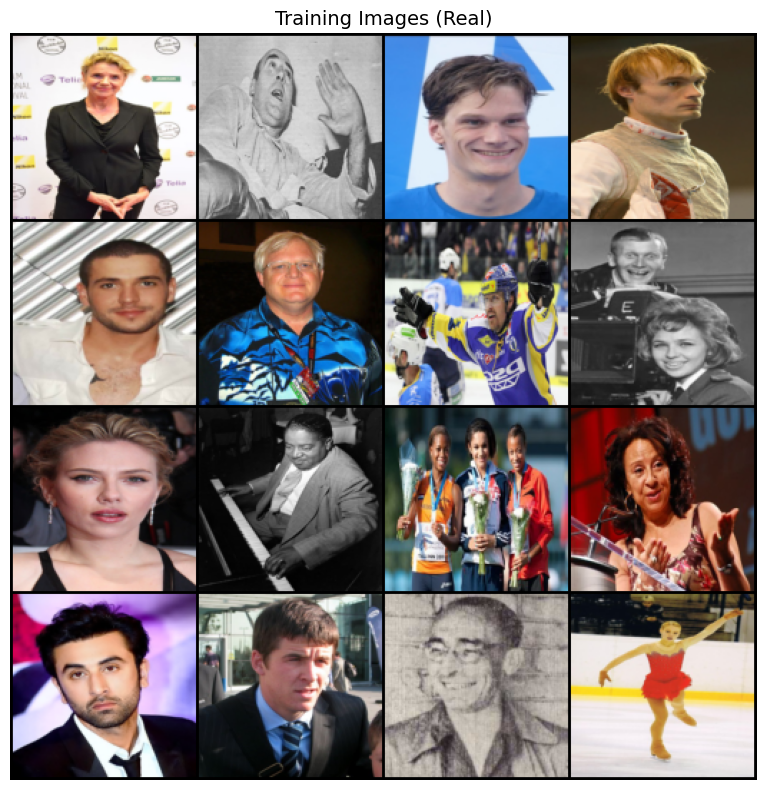

In [154]:
# ── Visualise a sample of training images ────────────────────────────────────
# Load directly - no need to spin up DataLoader workers for a preview
sample_imgs = []
for path in train_paths[:16]:
    img = Image.open(path).convert("RGB")
    sample_imgs.append(train_transform(img))

sample_batch = torch.stack(sample_imgs)
grid = vutils.make_grid(sample_batch, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.title("Training Images (Real)", fontsize=14)
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

## Utility Functions

Helper functions shared across all experiments: weight initialisation, checkpoint saving/loading, image grid generation, training curve plotting, logging, and FID (Fréchet Inception Distance) computation.

FID measures how similar the distribution of generated images is to the distribution of real images. We compute it using features from a pretrained Inception v3 network.

In [155]:
def weights_init(m):
    """DCGAN weight initialisation: N(0, 0.02) for Conv/ConvTranspose, 1/0 for BN."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def save_checkpoint(state, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(state, path)


def load_checkpoint(path, generator, discriminator, opt_g, opt_d):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    generator.load_state_dict(ckpt["generator"])
    discriminator.load_state_dict(ckpt["discriminator"])
    opt_g.load_state_dict(ckpt["opt_g"])
    opt_d.load_state_dict(ckpt["opt_d"])
    return ckpt["epoch"], ckpt["history"]


def denorm(tensor):
    """Convert from [-1,1] back to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

In [156]:
def save_image_grid(generator, fixed_noise, epoch, save_dir, nrow=8):
    """Save generated image grid to file - no display."""
    os.makedirs(save_dir, exist_ok=True)
    generator.eval()
    with torch.no_grad():
        fake = generator(fixed_noise).cpu()
    generator.train()
    grid = vutils.make_grid(fake, nrow=nrow, normalize=True, value_range=(-1, 1))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title(f"Generated Faces - Epoch {epoch}", fontsize=13)
    fig.tight_layout()
    path = os.path.join(save_dir, f"epoch_{epoch:04d}.png")
    fig.savefig(path, dpi=100, bbox_inches="tight")
    plt.close(fig)  # never call plt.show()
    print(f"  [saved] {path}", flush=True)


def plot_training_curves(history, title="Training Curves", log_path=None):
    """Save training curves to file - no display."""
    epochs = range(1, len(history["G_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=14)

    axes[0].plot(epochs, history["G_loss"], label="Generator Loss",     color="steelblue")
    axes[0].plot(epochs, history["D_loss"], label="Discriminator Loss", color="tomato")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Generator vs Discriminator Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["D_x"],  label="D(x)   - real",  color="forestgreen")
    axes[1].plot(epochs, history["D_Gz"], label="D(G(z)) - fake", color="darkorange")
    axes[1].axhline(0.5, linestyle="--", color="grey", alpha=0.6, label="Ideal = 0.5")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean Discriminator Output")
    axes[1].set_title("Discriminator Confidence")
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if log_path:
        fig.savefig(log_path, dpi=100, bbox_inches="tight")
        print(f"  [saved] {log_path}", flush=True)
    plt.close(fig)


def log_epoch(log_file, epoch, g_loss, d_loss, d_x, d_gz, fid=None):
    fid_str = f", FID {fid:.2f}" if fid is not None else ""
    line = (f"Epoch {epoch:03d} | G_loss {g_loss:.4f}, D_loss {d_loss:.4f} "
            f"| D(x) {d_x:.4f}, D(G(z)) {d_gz:.4f}{fid_str}\n")
    # Write to log file
    with open(log_file, "a") as f:
        f.write(line)
    # Print immediately - flush=True forces it out without buffering
    print(line, end="", flush=True)

In [157]:
# ── FID (Fréchet Inception Distance) ─────────────────────────────────────────
_inception_model = None

def _get_inception():
    global _inception_model
    if _inception_model is None:
        model = inception_v3(weights="IMAGENET1K_V1", transform_input=False)
        model.fc = nn.Identity()
        model.aux_logits = False
        model.eval()
        _inception_model = model.to(device)
    return _inception_model


@torch.no_grad()
def _extract_features(images_tensor, batch_size=64):
    model = _get_inception()
    feats = []
    for i in range(0, len(images_tensor), batch_size):
        batch = images_tensor[i:i + batch_size].to(device)
        batch = F.interpolate(batch, size=(299, 299), mode="bilinear",
                              align_corners=False, antialias=True)
        feats.append(model(batch).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_images_tensor, generator, n_samples=512):
    """Computes FID between real images and n_samples generated images."""
    # Real features
    idx = torch.randperm(len(real_images_tensor))[:n_samples]
    real_feats = _extract_features(real_images_tensor[idx])

    # Fake features
    generator.eval()
    noise = torch.randn(n_samples, LATENT_DIM, device=device)
    fake_imgs = []
    for i in range(0, n_samples, 64):
        fake_imgs.append(generator(noise[i:i + 64]).cpu())
    fake_imgs = torch.cat(fake_imgs, dim=0)
    generator.train()
    fake_feats = _extract_features(fake_imgs)

    # Fréchet distance
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))
    return fid


# ── Pre-collect real image pool - load directly, no DataLoader workers ────────
print("Collecting real image pool for FID evaluation...")
fid_paths = random.sample(train_paths, 512)
fid_real_pool = torch.stack([
    train_transform(Image.open(p).convert("RGB")) for p in fid_paths
])
print(f"FID pool ready: {fid_real_pool.shape}")  # (512, 3, 128, 128)

FID pool ready: torch.Size([512, 3, 128, 128])


## GANs Training Loops

Training functions for all GAN model variants. Each loop handles checkpointing, resume logic, periodic FID evaluation, and logging.

In [158]:
def train_dcgan(
    generator, discriminator,
    opt_g, opt_d,
    loader,
    epochs,
    experiment_name,
    base_log_dir="experiment_logs/generators",
    fixed_noise=None,
    label_smoothing=0.0,    # 0.0 = no smoothing (Iteration 1)
    n_critic=1,             # how many D steps per G step
    fid_every=5,            # compute FID every N epochs (expensive)
    resume=True,
):
    """
    Generic DCGAN training loop shared by both iterations.
    Returns history dict with per-epoch metrics.
    """
    log_dir  = os.path.join(base_log_dir, experiment_name)
    img_dir  = os.path.join(log_dir, "images")
    ckpt_path = os.path.join(log_dir, "checkpoint.pt")
    log_file  = os.path.join(log_dir, "logs.txt")
    os.makedirs(img_dir, exist_ok=True)

    if fixed_noise is None:
        fixed_noise = torch.randn(64, LATENT_DIM, device=device)

    criterion = nn.BCEWithLogitsLoss()

    history = {"G_loss": [], "D_loss": [], "D_x": [], "D_Gz": [], "FID": []}
    best_fid = float('inf')
    start_epoch = 1

    # ── Resume if checkpoint exists ───────────────────────────────────────────
    if resume and os.path.exists(ckpt_path):
        print(f"[RESUME] Loading checkpoint from {ckpt_path}")
        start_epoch, history = load_checkpoint(
            ckpt_path, generator, discriminator, opt_g, opt_d)
        start_epoch += 1
        print(f"  Resuming from epoch {start_epoch}")

    generator.train()
    discriminator.train()

    for epoch in range(start_epoch, epochs + 1):
        g_losses, d_losses, dx_vals, dgz_vals = [], [], [], []

        for i, real_imgs in enumerate(loader):
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # ── Labels (with optional smoothing) ──────────────────────────────
            real_label = torch.full((bs,), 1.0 - label_smoothing, device=device)
            fake_label = torch.zeros(bs, device=device)

            # ── Train Discriminator ───────────────────────────────────────────
            for _ in range(n_critic):
                discriminator.zero_grad()
                # Real
                out_real = discriminator(real_imgs)
                d_loss_real = criterion(out_real, real_label)
                # Fake
                noise = torch.randn(bs, LATENT_DIM, device=device)
                fake_imgs = generator(noise).detach()
                out_fake = discriminator(fake_imgs)
                d_loss_fake = criterion(out_fake, fake_label)
                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                opt_d.step()

            # D(x) and D(G(z)) for logging (before G update)
            dx_vals.append(torch.sigmoid(out_real).mean().item())
            dgz_vals.append(torch.sigmoid(out_fake).mean().item())

            # ── Train Generator ───────────────────────────────────────────────
            generator.zero_grad()
            noise = torch.randn(bs, LATENT_DIM, device=device)
            fake_imgs = generator(noise)
            out_fake2 = discriminator(fake_imgs)
            # Generator wants discriminator to believe fakes are real
            g_loss = criterion(out_fake2, torch.ones(bs, device=device))
            g_loss.backward()
            opt_g.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        # ── Epoch-level metrics ───────────────────────────────────────────────
        mean_g  = np.mean(g_losses)
        mean_d  = np.mean(d_losses)
        mean_dx = np.mean(dx_vals)
        mean_dgz = np.mean(dgz_vals)

        # FID (computed every fid_every epochs - it is slow)
        fid = None
        if epoch % fid_every == 0:
            fid = compute_fid(fid_real_pool, generator)
            history["FID"].append((epoch, fid))
            
            if fid < best_fid:
                best_fid = fid
                best_model_path = os.path.join(log_dir, "generator_best.pt")
                torch.save(generator.state_dict(), best_model_path)
                print(f"  --> New best generator saved with FID: {best_fid:.2f}")


        history["G_loss"].append(mean_g)
        history["D_loss"].append(mean_d)
        history["D_x"].append(mean_dx)
        history["D_Gz"].append(mean_dgz)

        log_epoch(log_file, epoch, mean_g, mean_d, mean_dx, mean_dgz, fid)

        # Save image grid every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            save_image_grid(generator, fixed_noise, epoch, img_dir)

        # Checkpoint every 10 epochs
        if epoch % 10 == 0:
            save_checkpoint({
                "epoch": epoch,
                "generator":     generator.state_dict(),
                "discriminator": discriminator.state_dict(),
                "opt_g":         opt_g.state_dict(),
                "opt_d":         opt_d.state_dict(),
                "history":       history,
            }, ckpt_path)

    # Save final history to JSON
    with open(os.path.join(log_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    return generator, discriminator, history

In [159]:
def gradient_penalty(critic, real_imgs, fake_imgs, device, lambda_gp=10):
    """
    Computes the gradient penalty for WGAN-GP.

    Creates interpolated images between real and fake, passes them through
    the critic, and penalises gradients that deviate from norm 1.
    lambda_gp=10 is the standard value from the original paper.
    """
    bs = real_imgs.size(0)
    # Random interpolation coefficient per image in batch
    alpha = torch.rand(bs, 1, 1, 1, device=device)
    # Interpolate between real and fake
    interpolated = (alpha * real_imgs + (1 - alpha) * fake_imgs.detach()).requires_grad_(True)
    # Critic score on interpolated images
    d_interp = critic(interpolated)
    # Compute gradients w.r.t. interpolated images
    gradients = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
    )[0]
    # Flatten gradients and compute their L2 norm
    gradients = gradients.view(bs, -1)
    gradient_norm = gradients.norm(2, dim=1)
    # Penalty: (||gradient|| - 1)^2
    gp = lambda_gp * ((gradient_norm - 1) ** 2).mean()
    return gp

In [160]:
def train_wgangp(
    generator, critic,
    opt_g, opt_c,
    loader,
    epochs,
    experiment_name,
    base_log_dir="experiment_logs/generators",
    fixed_noise=None,
    n_critic=5,        # train critic 5x per generator step
    lambda_gp=10,      # gradient penalty weight
    fid_every=10,
    resume=True,
):
    """
    WGAN-GP training loop.

    Key differences from train_dcgan:
    - No BCE loss - uses Wasserstein loss
    - Critic trained n_critic times per generator step
    - Gradient penalty added to critic loss
    - Tracks W-distance (should increase then stabilise)
    """
    log_dir   = os.path.join(base_log_dir, experiment_name)
    img_dir   = os.path.join(log_dir, "images")
    ckpt_path = os.path.join(log_dir, "checkpoint.pt")
    log_file  = os.path.join(log_dir, "logs.txt")
    os.makedirs(img_dir, exist_ok=True)

    if fixed_noise is None:
        fixed_noise = torch.randn(64, LATENT_DIM, device=device)

    history = {"G_loss": [], "C_loss": [], "W_dist": [], "GP": [], "FID": []}
    best_fid = float('inf')
    start_epoch = 1

    # Resume from checkpoint if available
    if resume and os.path.exists(ckpt_path):
        print(f"[RESUME] Loading checkpoint from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        generator.load_state_dict(ckpt["generator"])
        critic.load_state_dict(ckpt["critic"])
        opt_g.load_state_dict(ckpt["opt_g"])
        opt_c.load_state_dict(ckpt["opt_c"])
        start_epoch = ckpt["epoch"] + 1
        history = ckpt["history"]
        print(f"  Resuming from epoch {start_epoch}")

    generator.train()
    critic.train()

    for epoch in range(start_epoch, epochs + 1):
        g_losses, c_losses, w_dists, gps = [], [], [], []

        for i, real_imgs in enumerate(loader):
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # ── Train Critic n_critic times ───────────────────────────────────
            for _ in range(n_critic):
                critic.zero_grad()
                noise = torch.randn(bs, LATENT_DIM, device=device)
                fake_imgs = generator(noise).detach()

                # Wasserstein loss: maximise critic(real) - critic(fake)
                c_real = critic(real_imgs).mean()
                c_fake = critic(fake_imgs).mean()
                gp     = gradient_penalty(critic, real_imgs, fake_imgs, device, lambda_gp)
                c_loss = c_fake - c_real + gp   # minimise this
                c_loss.backward()
                opt_c.step()

            # Log critic metrics (W-distance is real - fake, higher = better)
            w_dist = (c_real - c_fake).item()
            w_dists.append(w_dist)
            c_losses.append(c_loss.item())
            gps.append(gp.item())

            # ── Train Generator ───────────────────────────────────────────────
            generator.zero_grad()
            noise = torch.randn(bs, LATENT_DIM, device=device)
            fake_imgs = generator(noise)
            # Generator wants critic to score fakes as high as possible
            g_loss = -critic(fake_imgs).mean()
            g_loss.backward()
            opt_g.step()
            g_losses.append(g_loss.item())

        # ── Epoch metrics ─────────────────────────────────────────────────────
        mean_g  = np.mean(g_losses)
        mean_c  = np.mean(c_losses)
        mean_w  = np.mean(w_dists)
        mean_gp = np.mean(gps)

        fid = None
        if epoch % fid_every == 0:
            fid = compute_fid(fid_real_pool, generator)
            history["FID"].append((epoch, fid))
            if fid < best_fid:
                best_fid = fid
                best_model_path = os.path.join(log_dir, "generator_best.pt")
                torch.save(generator.state_dict(), best_model_path)
                print(f"  --> New best generator saved with FID: {best_fid:.2f}")


        history["G_loss"].append(mean_g)
        history["C_loss"].append(mean_c)
        history["W_dist"].append(mean_w)
        history["GP"].append(mean_gp)

        # Log
        fid_str = f", FID {fid:.2f}" if fid is not None else ""
        line = (f"Epoch {epoch:03d} | G_loss {mean_g:.4f}, C_loss {mean_c:.4f} "
                f"| W_dist {mean_w:.4f}, GP {mean_gp:.4f}{fid_str}\n")
        os.makedirs(os.path.dirname(log_file), exist_ok=True)
        with open(log_file, "a") as f:
            f.write(line)
        print(line, end="", flush=True)

        if epoch % 5 == 0 or epoch == 1:
            save_image_grid(generator, fixed_noise, epoch, img_dir)

        if epoch % 10 == 0:
            torch.save({
                "epoch": epoch,
                "generator": generator.state_dict(),
                "critic":    critic.state_dict(),
                "opt_g":     opt_g.state_dict(),
                "opt_c":     opt_c.state_dict(),
                "history":   history,
            }, ckpt_path)

    with open(os.path.join(log_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    return generator, critic, history

---
## Option 1 - Baseline DCGAN

A DCGAN (Deep Convolutional GAN) consists of two networks trained against each other. The **generator** takes a random noise vector (100 dimensions) and transforms it through a series of upsampling layers into a 128×128 image. The **discriminator** takes an image and outputs whether it thinks the image is real or fake.

Training alternates between the two: the discriminator learns to tell real from fake, and the generator learns to fool the discriminator. The hope is that this adversarial pressure pushes the generator to produce increasingly realistic images.

For this baseline we use a standard DCGAN setup:
- Generator with BatchNorm and ReLU, Tanh output
- Discriminator with BatchNorm and LeakyReLU
- Adam optimiser with lr=0.0002 and β₁=0.5 for both networks
- Binary cross-entropy loss

In [161]:
LATENT_DIM = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models
gen_v1 = Generator_v1(latent_dim=LATENT_DIM).to(device)
disc_v1 = Discriminator_v1().to(device)

# Quick Sanity Check
with torch.no_grad():
    test_noise = torch.randn(4, LATENT_DIM).to(device)
    fake_images = gen_v1(test_noise)
    predictions = disc_v1(fake_images)
    
    print(f"Generator output shape: {fake_images.shape}")  # Expected: [4, 3, 128, 128]
    print(f"Discriminator output shape: {predictions.shape}")

Generator output shape: torch.Size([4, 3, 128, 128])
Discriminator output shape: torch.Size([4])


In [162]:
# ── Run Iteration 1 ───────────────────────────────────────────────────────────
EPOCHS_V1     = 250
_v1_hist_path = os.path.join("experiment_logs/generators", "DCGAN_v1", "history.json")
_v1_ckpt      = os.path.join("experiment_logs/generators", "DCGAN_v1", "checkpoint.pt")
_v1_done      = False

if os.path.exists(_v1_hist_path):
    with open(_v1_hist_path) as _f:
        history_v1 = json.load(_f)
    _v1_epochs_done = len(history_v1.get("G_loss", []))
    if _v1_epochs_done >= EPOCHS_V1:
        print(f"Option 1 already complete ({_v1_epochs_done}/{EPOCHS_V1} epochs in history.json). Skipping training.")
        _v1_done = True
    elif os.path.exists(_v1_ckpt):
        print(f"Option 1 partial ({_v1_epochs_done}/{EPOCHS_V1} epochs) - resuming from checkpoint.")
    else:
        print(f"Option 1 partial ({_v1_epochs_done}/{EPOCHS_V1} epochs) - no checkpoint, restarting from scratch.")
elif os.path.exists(_v1_ckpt):
    print("Option 1 checkpoint found but no history.json - will resume from checkpoint.")

fixed_noise = torch.randn(64, LATENT_DIM, device=device)

if not _v1_done:
    LR_V1   = 2e-4
    gen_v1  = Generator_v1().to(device)
    disc_v1 = Discriminator_v1().to(device)
    gen_v1.apply(weights_init)
    disc_v1.apply(weights_init)

    opt_g_v1 = torch.optim.Adam(gen_v1.parameters(),  lr=LR_V1, betas=(0.5, 0.999))
    opt_d_v1 = torch.optim.Adam(disc_v1.parameters(), lr=LR_V1, betas=(0.5, 0.999))

    print(f"Generator     parameters: {sum(p.numel() for p in gen_v1.parameters()):,}")
    print(f"Discriminator parameters: {sum(p.numel() for p in disc_v1.parameters()):,}")

    gen_v1, disc_v1, history_v1 = train_dcgan(
        gen_v1, disc_v1,
        opt_g_v1, opt_d_v1,
        train_loader,
        epochs=EPOCHS_V1,
        experiment_name="DCGAN_v1",
        fixed_noise=fixed_noise,
        label_smoothing=0.0,
        fid_every=10,
    )


Option 1 already complete (250/250 epochs in history.json). Skipping training.


In [163]:
if not _v1_done:
    torch.save(gen_v1.state_dict(), "experiment_logs/generators/DCGAN_v1/generator_final.pt")
    print("Generator v1 saved!")
else:
    print("Generator v1 already saved.")

Generator v1 already saved.


### Option 1 - Results & Analysis

**FID:** Started at 241 (epoch 10) and improved to 133 (epoch 250). The model is learning, but the score remains high.

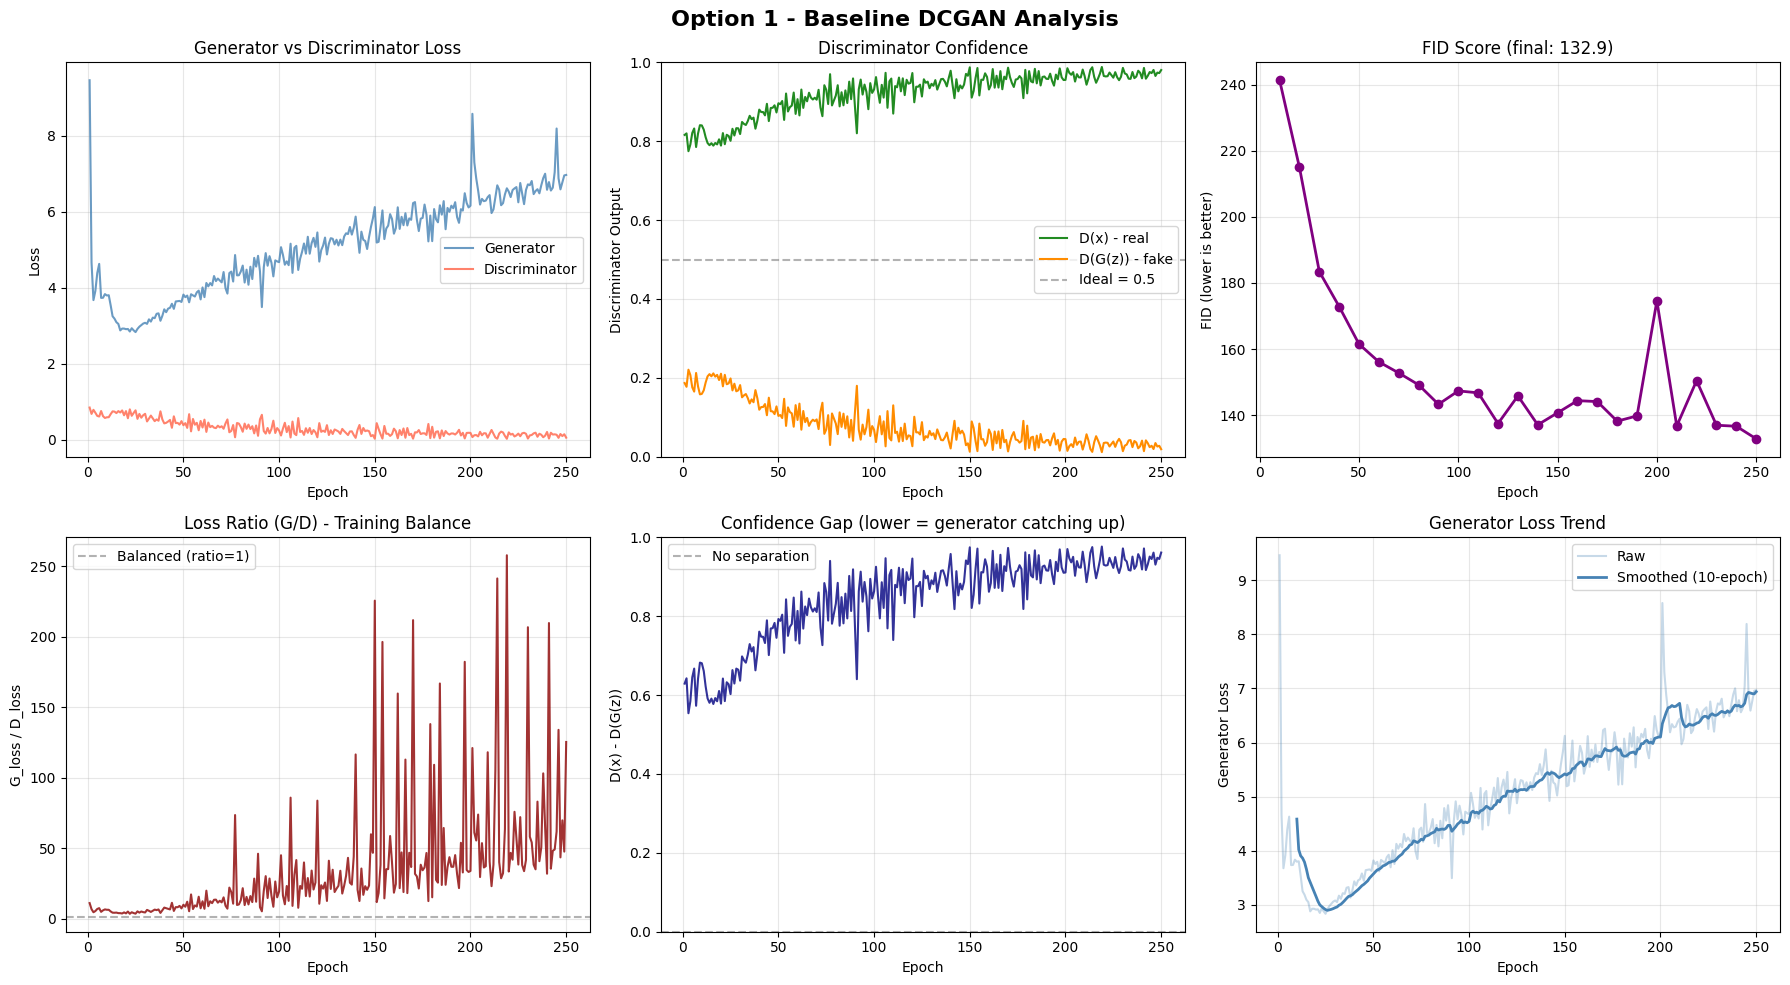

OPTION 1 - BASELINE DCGAN SUMMARY
  Epochs trained     : 250
  Final G_loss       : 6.9713
  Final D_loss       : 0.0556
  Final D(x)         : 0.9804  (ideal: 0.5)
  Final D(G(z))      : 0.0190  (ideal: 0.5)
  Final loss ratio   : 125.4x
  Best FID           : 132.86 (epoch 250)
  Final FID          : 132.86


In [164]:
# ── Option 1 - Full Analysis ─────────────────────────────────────────────────
v1_history_path = os.path.join("experiment_logs/generators", "DCGAN_v1", "history.json")
if 'history_v1' not in locals() and os.path.exists(v1_history_path):
    with open(v1_history_path) as f:
        history_v1 = json.load(f)

epochs_v1 = range(1, len(history_v1["G_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Option 1 - Baseline DCGAN Analysis", fontsize=16, fontweight="bold")

# 1. Generator vs Discriminator Loss
axes[0, 0].plot(epochs_v1, history_v1["G_loss"], label="Generator", color="steelblue", alpha=0.8)
axes[0, 0].plot(epochs_v1, history_v1["D_loss"], label="Discriminator", color="tomato", alpha=0.8)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Generator vs Discriminator Loss")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Discriminator Confidence
axes[0, 1].plot(epochs_v1, history_v1["D_x"], label="D(x) - real", color="forestgreen")
axes[0, 1].plot(epochs_v1, history_v1["D_Gz"], label="D(G(z)) - fake", color="darkorange")
axes[0, 1].axhline(0.5, linestyle="--", color="grey", alpha=0.6, label="Ideal = 0.5")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Discriminator Output")
axes[0, 1].set_title("Discriminator Confidence")
axes[0, 1].set_ylim(0, 1); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. FID Score
if history_v1["FID"]:
    fid_epochs, fid_scores = zip(*history_v1["FID"])
    axes[0, 2].plot(fid_epochs, fid_scores, marker="o", color="purple", linewidth=2)
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("FID (lower is better)")
    axes[0, 2].set_title(f"FID Score (final: {fid_scores[-1]:.1f})")
    axes[0, 2].grid(True, alpha=0.3)

# 4. Loss Ratio (G/D) - shows how imbalanced training is
g_arr = np.array(history_v1["G_loss"])
d_arr = np.array(history_v1["D_loss"])
ratio = g_arr / (d_arr + 1e-8)
axes[1, 0].plot(epochs_v1, ratio, color="darkred", alpha=0.8)
axes[1, 0].axhline(1.0, linestyle="--", color="grey", alpha=0.6, label="Balanced (ratio=1)")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("G_loss / D_loss")
axes[1, 0].set_title("Loss Ratio (G/D) - Training Balance")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 5. Discriminator Confidence Gap - how easily D separates real from fake
gap = np.array(history_v1["D_x"]) - np.array(history_v1["D_Gz"])
axes[1, 1].plot(epochs_v1, gap, color="navy", alpha=0.8)
axes[1, 1].axhline(0.0, linestyle="--", color="grey", alpha=0.6, label="No separation")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("D(x) - D(G(z))")
axes[1, 1].set_title("Confidence Gap (lower = generator catching up)")
axes[1, 1].set_ylim(0, 1); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 6. Generator Loss (smoothed) - easier to see the trend
window = 10
g_smooth = np.convolve(history_v1["G_loss"], np.ones(window)/window, mode="valid")
axes[1, 2].plot(epochs_v1, history_v1["G_loss"], alpha=0.3, color="steelblue", label="Raw")
axes[1, 2].plot(range(window, len(g_smooth) + window), g_smooth, color="steelblue", linewidth=2, label=f"Smoothed ({window}-epoch)")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Generator Loss")
axes[1, 2].set_title("Generator Loss Trend")
axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("experiment_logs/generators", "DCGAN_v1", "full_analysis.png"), dpi=150)
plt.show()

# ── Summary Statistics ────────────────────────────────────────────────────────
print("=" * 60)
print("OPTION 1 - BASELINE DCGAN SUMMARY")
print("=" * 60)
print(f"  Epochs trained     : {len(history_v1['G_loss'])}")
print(f"  Final G_loss       : {history_v1['G_loss'][-1]:.4f}")
print(f"  Final D_loss       : {history_v1['D_loss'][-1]:.4f}")
print(f"  Final D(x)         : {history_v1['D_x'][-1]:.4f}  (ideal: 0.5)")
print(f"  Final D(G(z))      : {history_v1['D_Gz'][-1]:.4f}  (ideal: 0.5)")
print(f"  Final loss ratio   : {history_v1['G_loss'][-1] / (history_v1['D_loss'][-1] + 1e-8):.1f}x")
if history_v1["FID"]:
    print(f"  Best FID           : {min(fid_scores):.2f} (epoch {fid_epochs[fid_scores.index(min(fid_scores))]})")
    print(f"  Final FID          : {fid_scores[-1]:.2f}")
print("=" * 60)


**Generator vs Discriminator Loss:** The discriminator loss drops to near zero while the generator loss climbs from ~3 to ~7. This is the clearest sign of discriminator dominance, the discriminator is solving its task easily while the generator falls further behind.

**Discriminator Confidence:** D(x) climbs to ~0.98 and D(G(z)) drops to ~0.02. In a healthy GAN, both values should hover around 0.5, meaning the discriminator is unsure whether images are real or fake. Here, it is almost perfectly certain on every image, which means the generated faces are still easily distinguishable from real ones.

**FID Score:** Drops from 241 to 133 over 250 epochs, showing the generator does learn meaningful structure. However, the improvement slows down significantly after epoch 50, suggesting the model is hitting a ceiling imposed by the training instability.

**Loss Ratio (G/D):** This ratio spikes to over 200x in later epochs. A balanced training would keep this near 1. The extreme imbalance confirms that the discriminator is learning much faster than the generator, starving it of useful gradient information.

**Confidence Gap:** D(x) - D(G(z)) approaches 1.0 (the maximum possible gap), meaning the discriminator separates real and fake images almost perfectly. There is no sign of the generator closing this gap in later epochs.

**Generator Loss Trend:** The smoothed curve shows a clear upward trend after epoch 50. Instead of the generator getting better over time, it is getting worse - a direct consequence of the vanishing gradients from the over-confident discriminator.

**Conclusion:** The baseline DCGAN learns basic face structure (FID improves from 241 to 133) but suffers from discriminator dominance. The discriminator becomes too powerful too quickly, and the BCE loss saturates, leaving the generator with near-zero gradients. In Option 2, we address this with spectral normalisation (to constrain the discriminator), label smoothing (to prevent overconfidence), and separate learning rates for each network.

In [165]:
if not _v1_done:
    save_image_grid(gen_v1, fixed_noise, epoch=9999,
                    save_dir=os.path.join("experiment_logs/generators", "DCGAN_v1", "images"))

Loading latest result


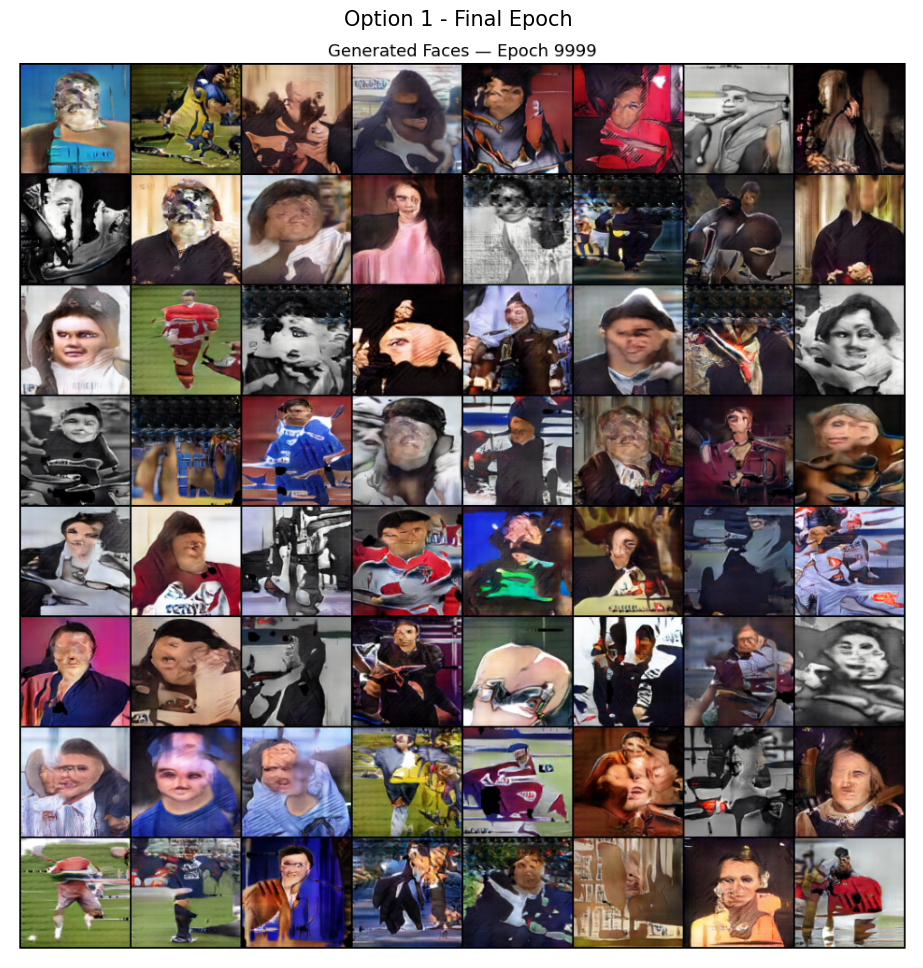

In [166]:
img_dir = "experiment_logs/generators/DCGAN_v1/images/"

# Find and sort all saved grid images
image_files = glob(os.path.join(img_dir, "epoch_*.png"))
image_files.sort()

if image_files:
    latest_image_path = image_files[-1]
    epoch_str = os.path.basename(latest_image_path).replace('epoch_', '').replace('.png', '')
    
    print(f"Loading latest result")
    
    img = Image.open(latest_image_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Option 1 - Final Epoch ", fontsize=15)
    plt.show()
else:
    print(f"No images found in {img_dir}. Check if the experiment_name matches.")

---
## Option 2 - Improved DCGAN

Option 1 showed that the baseline DCGAN's main problem was discriminator dominance, it learned to separate real from fake too easily, leaving the generator with vanishing gradients. In this iteration we apply three standard techniques to address this:

- **Spectral Normalisation** on the discriminator: constrains the Lipschitz constant of each layer, preventing the discriminator from becoming arbitrarily confident. This replaces BatchNorm in the discriminator.
- **Label Smoothing** (0.15): instead of training the discriminator with hard labels (real=1, fake=0), we use real=0.85. This softens the discriminator's confidence and keeps the gradient signal alive.
- **Two Time-Scale Update Rule (TTUR)**: the generator uses a higher learning rate (2e-4) than the discriminator (1e-4), giving the generator a head start in each training step.

We also increase the generator capacity from ngf=64 to ngf=128, doubling the number of filters per layer so it can model finer facial details.

In [167]:
LATENT_DIM = 100

# Initialize Iteration 2
gen_v2 = Generator_v2(latent_dim=LATENT_DIM).to(device)
disc_v2 = Discriminator_v2().to(device)

# Sanity Check
with torch.no_grad():
    noise = torch.randn(4, LATENT_DIM).to(device)
    fake = gen_v2(noise)
    print(f"Generator_v2 output shape: {fake.shape}")
    print(f"Discriminator_v2 params: {sum(p.numel() for p in disc_v2.parameters()):,}")

Generator_v2 output shape: torch.Size([4, 3, 128, 128])
Discriminator_v2 params: 2,788,352


In [168]:
# ── Run Iteration 2 ───────────────────────────────────────────────────────────
EPOCHS_V2     = 100
_v2_hist_path = os.path.join("experiment_logs/generators", "DCGAN_v2", "history.json")
_v2_ckpt      = os.path.join("experiment_logs/generators", "DCGAN_v2", "checkpoint.pt")
_v2_done      = False

if os.path.exists(_v2_hist_path):
    with open(_v2_hist_path) as _f:
        history_v2 = json.load(_f)
    _v2_epochs_done = len(history_v2.get("G_loss", []))
    if _v2_epochs_done >= EPOCHS_V2:
        print(f"Option 2 already complete ({_v2_epochs_done}/{EPOCHS_V2} epochs in history.json). Skipping training.")
        _v2_done = True
    elif os.path.exists(_v2_ckpt):
        print(f"Option 2 partial ({_v2_epochs_done}/{EPOCHS_V2} epochs) - resuming from checkpoint.")
    else:
        print(f"Option 2 partial ({_v2_epochs_done}/{EPOCHS_V2} epochs) - no checkpoint, restarting from scratch.")
elif os.path.exists(_v2_ckpt):
    print("Option 2 checkpoint found but no history.json - will resume from checkpoint.")

if not _v2_done:
    LR_D_V2            = 1e-4   # was 2e-4 - slow D down more
    LR_G_V2            = 2e-4   # was 1e-4 - speed G up (flip the TTUR)
    LABEL_SMOOTHING_V2 = 0.15   # was 0.05 - more aggressive smoothing

    gen_v2  = Generator_v2().to(device)
    disc_v2 = Discriminator_v2().to(device)
    gen_v2.apply(weights_init)
    disc_v2.apply(weights_init)

    opt_g_v2 = torch.optim.Adam(gen_v2.parameters(),  lr=LR_G_V2, betas=(0.5, 0.999))
    opt_d_v2 = torch.optim.Adam(disc_v2.parameters(), lr=LR_D_V2, betas=(0.5, 0.999))

    print(f"Generator_v2     parameters: {sum(p.numel() for p in gen_v2.parameters()):,}")
    print(f"Discriminator_v2 parameters: {sum(p.numel() for p in disc_v2.parameters()):,}")

    gen_v2, disc_v2, history_v2 = train_dcgan(
        gen_v2, disc_v2,
        opt_g_v2, opt_d_v2,
        train_loader,
        epochs=EPOCHS_V2,
        experiment_name="DCGAN_v2",
        fixed_noise=fixed_noise,
        label_smoothing=LABEL_SMOOTHING_V2,
        fid_every=10,
    )


Option 2 already complete (100/100 epochs in history.json). Skipping training.


In [169]:
if not _v2_done:
    torch.save(gen_v2.state_dict(), "experiment_logs/generators/DCGAN_v2/generator_final.pt")
    print("Generator v2 saved!")
else:
    print("Generator v2 already saved.")

Generator v2 already saved.


### Option 2 - Results

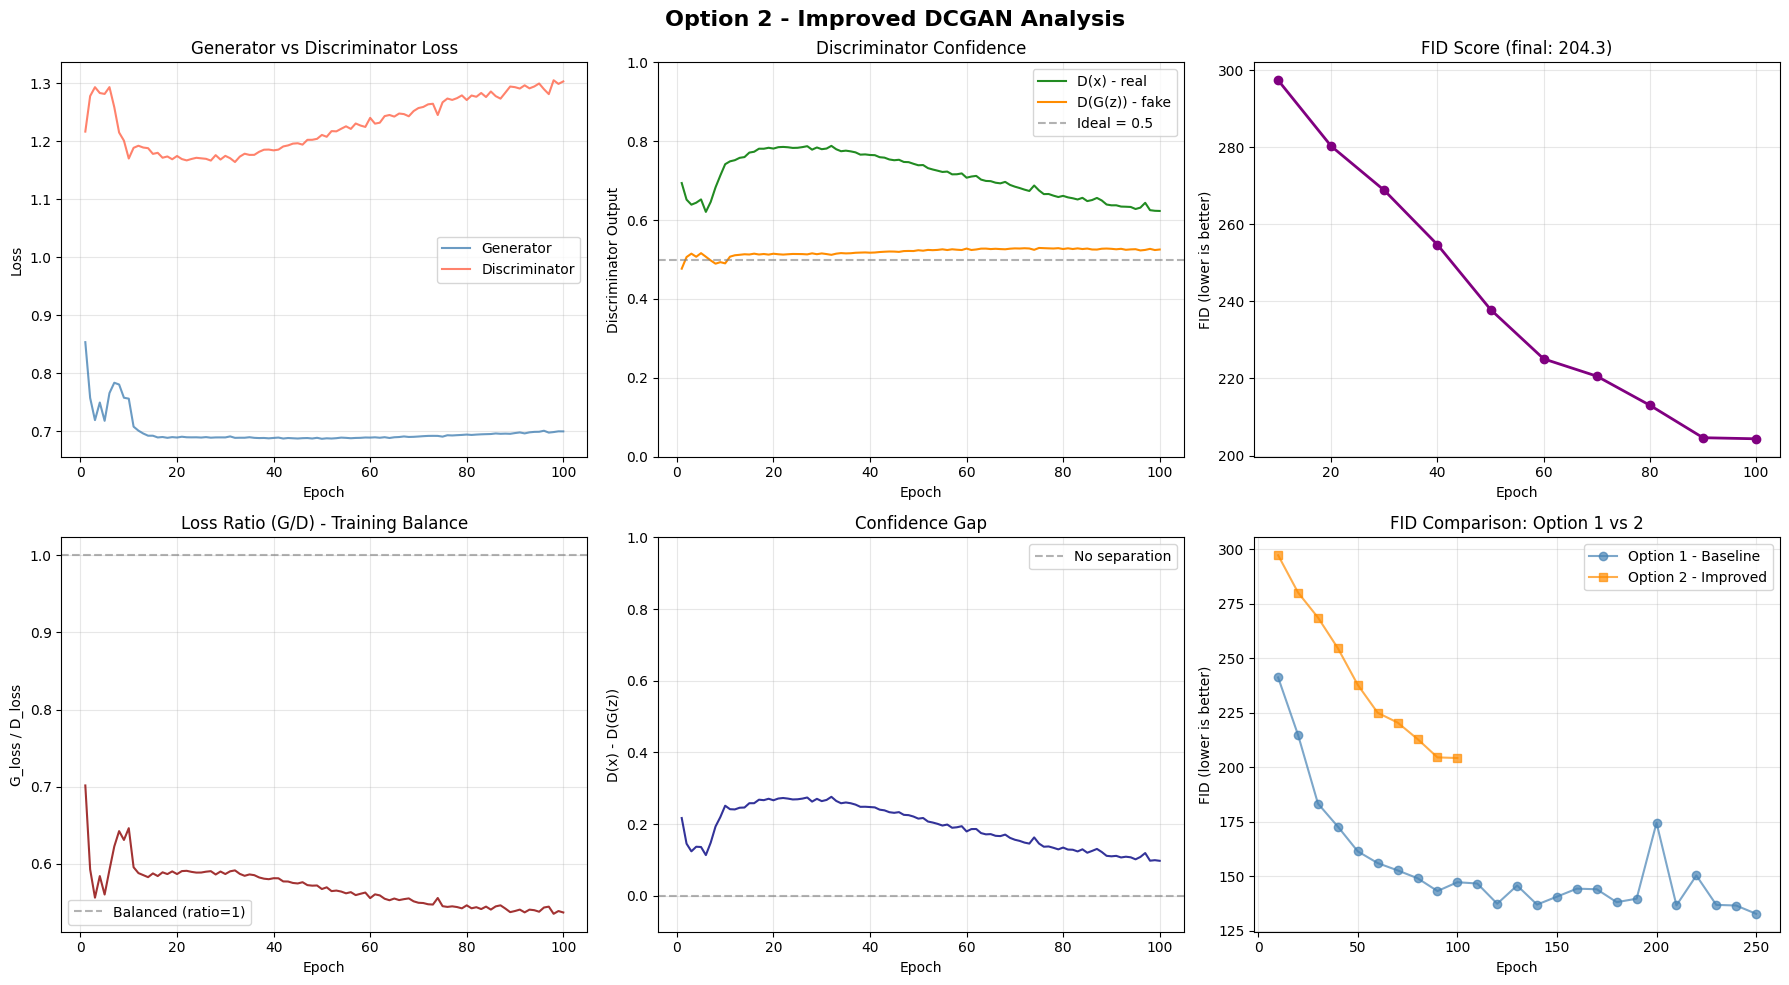

OPTION 2 - IMPROVED DCGAN SUMMARY
  Epochs trained     : 100
  Final G_loss       : 0.7002  (Option 1: 6.9713)
  Final D_loss       : 1.3035  (Option 1: 0.0556)
  Final D(x)         : 0.6232  (Option 1: 0.9804)
  Final D(G(z))      : 0.5254  (Option 1: 0.0190)
  Best FID           : 204.33 (epoch 100)
  Final FID          : 204.33  (Option 1: 132.86)


In [170]:
# ── Option 2 - Full Analysis ─────────────────────────────────────────────────
v2_history_path = os.path.join("experiment_logs/generators", "DCGAN_v2", "history.json")
if 'history_v2' not in locals() and os.path.exists(v2_history_path):
    with open(v2_history_path) as f:
        history_v2 = json.load(f)

epochs_v2 = range(1, len(history_v2["G_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Option 2 - Improved DCGAN Analysis", fontsize=16, fontweight="bold")

# 1. Generator vs Discriminator Loss
axes[0, 0].plot(epochs_v2, history_v2["G_loss"], label="Generator", color="steelblue", alpha=0.8)
axes[0, 0].plot(epochs_v2, history_v2["D_loss"], label="Discriminator", color="tomato", alpha=0.8)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Generator vs Discriminator Loss")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Discriminator Confidence
axes[0, 1].plot(epochs_v2, history_v2["D_x"], label="D(x) - real", color="forestgreen")
axes[0, 1].plot(epochs_v2, history_v2["D_Gz"], label="D(G(z)) - fake", color="darkorange")
axes[0, 1].axhline(0.5, linestyle="--", color="grey", alpha=0.6, label="Ideal = 0.5")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Discriminator Output")
axes[0, 1].set_title("Discriminator Confidence")
axes[0, 1].set_ylim(0, 1); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. FID Score
if history_v2["FID"]:
    fid_epochs, fid_scores = zip(*history_v2["FID"])
    axes[0, 2].plot(fid_epochs, fid_scores, marker="o", color="purple", linewidth=2)
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("FID (lower is better)")
    axes[0, 2].set_title(f"FID Score (final: {fid_scores[-1]:.1f})")
    axes[0, 2].grid(True, alpha=0.3)

# 4. Loss Ratio (G/D)
g_arr = np.array(history_v2["G_loss"])
d_arr = np.array(history_v2["D_loss"])
ratio = g_arr / (d_arr + 1e-8)
axes[1, 0].plot(epochs_v2, ratio, color="darkred", alpha=0.8)
axes[1, 0].axhline(1.0, linestyle="--", color="grey", alpha=0.6, label="Balanced (ratio=1)")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("G_loss / D_loss")
axes[1, 0].set_title("Loss Ratio (G/D) - Training Balance")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 5. Confidence Gap
gap = np.array(history_v2["D_x"]) - np.array(history_v2["D_Gz"])
axes[1, 1].plot(epochs_v2, gap, color="navy", alpha=0.8)
axes[1, 1].axhline(0.0, linestyle="--", color="grey", alpha=0.6, label="No separation")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("D(x) - D(G(z))")
axes[1, 1].set_title("Confidence Gap")
axes[1, 1].set_ylim(-0.1, 1); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 6. FID Comparison with Option 1
if history_v1["FID"] and history_v2["FID"]:
    fe1, fs1 = zip(*history_v1["FID"])
    fe2, fs2 = zip(*history_v2["FID"])
    axes[1, 2].plot(fe1, fs1, marker="o", label="Option 1 - Baseline", color="steelblue", alpha=0.7)
    axes[1, 2].plot(fe2, fs2, marker="s", label="Option 2 - Improved", color="darkorange", alpha=0.7)
    axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("FID (lower is better)")
    axes[1, 2].set_title("FID Comparison: Option 1 vs 2")
    axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("experiment_logs/generators", "DCGAN_v2", "full_analysis.png"), dpi=150)
plt.show()

# ── Summary Statistics ────────────────────────────────────────────────────────
print("=" * 60)
print("OPTION 2 - IMPROVED DCGAN SUMMARY")
print("=" * 60)
print(f"  Epochs trained     : {len(history_v2['G_loss'])}")
print(f"  Final G_loss       : {history_v2['G_loss'][-1]:.4f}  (Option 1: {history_v1['G_loss'][-1]:.4f})")
print(f"  Final D_loss       : {history_v2['D_loss'][-1]:.4f}  (Option 1: {history_v1['D_loss'][-1]:.4f})")
print(f"  Final D(x)         : {history_v2['D_x'][-1]:.4f}  (Option 1: {history_v1['D_x'][-1]:.4f})")
print(f"  Final D(G(z))      : {history_v2['D_Gz'][-1]:.4f}  (Option 1: {history_v1['D_Gz'][-1]:.4f})")
if history_v2["FID"]:
    print(f"  Best FID           : {min(fid_scores):.2f} (epoch {fid_epochs[fid_scores.index(min(fid_scores))]})")
    print(f"  Final FID          : {fid_scores[-1]:.2f}  (Option 1: {history_v1['FID'][-1][1]:.2f})")
print("=" * 60)

### Option 2 - Results & Analysis

**Training stability is dramatically improved.** Unlike Option 1's wild loss swings, both losses stay in a narrow band throughout training. The generator settles at ~0.70 and the discriminator at ~1.17-1.30. There are no spikes, no divergence ,the spectral normalisation and label smoothing successfully prevented the discriminator from dominating.

**However, the model has the opposite problem.** The generator loss sits at exactly 0.700, which is very close to −ln(0.5) = 0.693 (the theoretical equilibrium point where the discriminator outputs 0.5 for everything). D(G(z)) hovers at ~0.52 for the entire run, confirming this: the discriminator rates fake images as roughly 50/50 from the very beginning. The discriminator was constrained too much , it can never confidently separate real from fake, so the generator has no pressure to improve beyond producing vaguely image-like outputs.

**The confidence gap shrinks, but for the wrong reason.** D(x) drops from 0.78 toward 0.62 while D(G(z)) stays flat at 0.52. The gap is closing not because the generator is getting better, but because the discriminator is getting worse at recognising real images.

**The generated images reveal a colour shortcut.** Looking at the output grid, many generated images are grey or heavily desaturated. The generator discovered that by reducing colour saturation, it removes one of the easiest cues the discriminator could use to separate real from fake , real photos have natural, varied colour distributions, while early fake images have unrealistic colours. By making everything grey, the generator effectively "hides" in a safe zone where the over-constrained discriminator cannot penalise it. This is a form of mode collapse into a low-risk strategy rather than learning to produce realistic faces.

**FID confirms the failure.** Despite 100 epochs, FID only reaches 204, worse than Option 1's 147.34 after 100 epochs and 133 after 250 epochs. The FID comparison plot makes this clear: Option 1 learns faster even though its training is unstable. The improved DCGAN trades instability for stagnation.

**The core issue with BCE loss.** Both Options 1 and 2 reveal a fundamental limitation of binary cross-entropy loss: it either saturates (Option 1 - discriminator too strong) or reaches a trivial equilibrium (Option 2 - discriminator too constrained). There is no sweet spot that works reliably.

**What we take to Option 3:** Instead of trying to balance BCE loss, we abandon it entirely. WGAN-GP replaces the classification loss with a Wasserstein distance, which provides meaningful, non-saturating gradients regardless of how good the critic is. This sidesteps both failure modes we observed.

In [171]:
if not _v2_done:
    save_image_grid(gen_v2, fixed_noise, epoch=9999,
                    save_dir=os.path.join("experiment_logs/generators", "DCGAN_v2", "images"))

Loading latest Improved DCGAN result: experiment_logs/generators/DCGAN_v2/images\epoch_9999.png


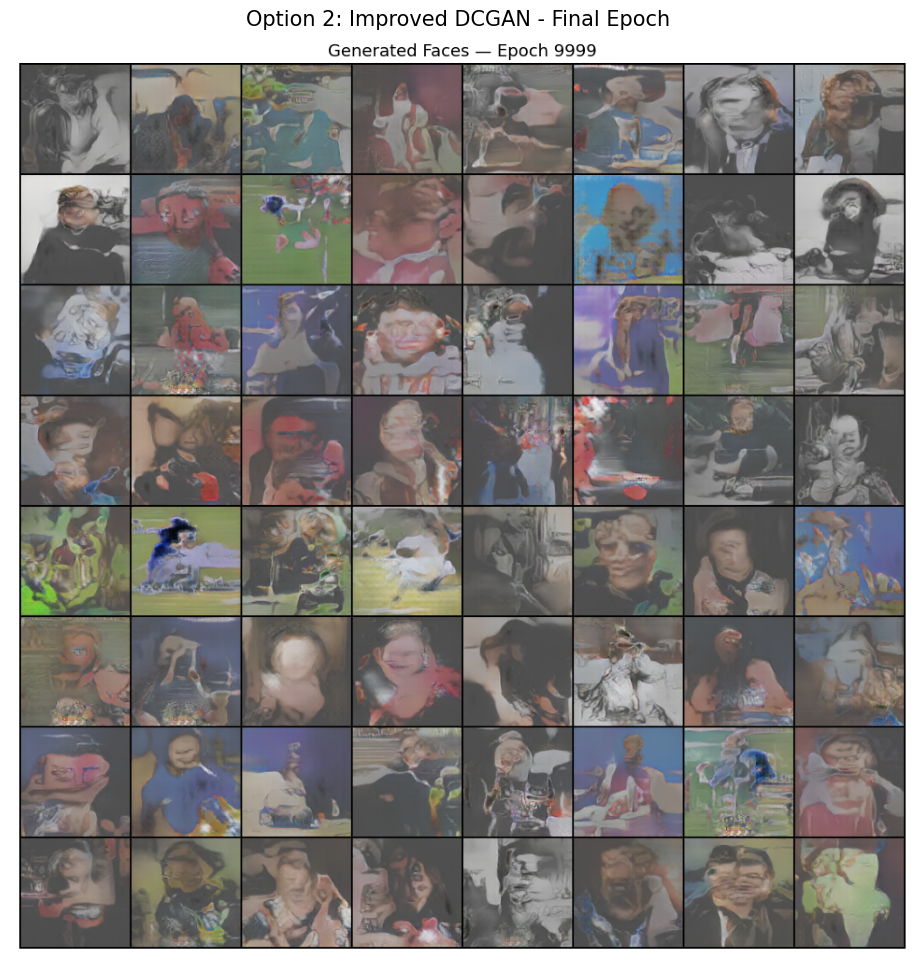

In [172]:
img_dir = "experiment_logs/generators/DCGAN_v2/images/"

# Find and sort all saved grid images
image_files = glob(os.path.join(img_dir, "epoch_*.png"))
image_files.sort()

if image_files:
    latest_image_path = image_files[-1]
    epoch_str = os.path.basename(latest_image_path).replace('epoch_', '').replace('.png', '')
    
    print(f"Loading latest Improved DCGAN result: {latest_image_path}")
    
    img = Image.open(latest_image_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Option 2: Improved DCGAN - Final Epoch ", fontsize=15)
    plt.show()
else:
    print(f"No images found in {img_dir}. Check if the experiment_name matches.")

---
## Option 3 - WGAN-GP (Wasserstein GAN with Gradient Penalty)

Options 1 and 2 showed that BCE loss is fundamentally problematic for GAN training - it either saturates when the discriminator is too strong (Option 1) or produces a lazy equilibrium when the discriminator is constrained (Option 2).

WGAN-GP replaces BCE with the **Wasserstein distance**. Instead of classifying images as real/fake, the critic outputs a raw score, no sigmoid, no probability. The loss is simply the difference in scores between real and fake images. This provides smooth, meaningful gradients to the generator regardless of how good the critic is.

The key changes from Option 2:
- **Wasserstein loss:** the critic maximises E[C(real)] - E[C(fake)], the generator minimises -E[C(fake)]. No log, no saturation.
- **Gradient Penalty (GP):** replaces weight clipping. Enforces a 1-Lipschitz constraint by penalising the critic when its gradient norm deviates from 1. This is computed on interpolations between real and fake images.
- **InstanceNorm instead of BatchNorm** in the critic: BatchNorm is incompatible with gradient penalty because GP requires per-sample gradients, while BatchNorm couples samples within a batch.
- **N_critic = 2:** the critic is trained 2 steps for every 1 generator step, giving it a more accurate distance estimate.

In [173]:
LATENT_DIM = 100

# Initialize
generator = Generator_v3(latent_dim=LATENT_DIM).to(device)
critic = Critic_v3().to(device)

# Test run
with torch.no_grad():
    z = torch.randn(1, LATENT_DIM).to(device)
    fake_img = generator(z)
    score = critic(fake_img)
    print(f"Generated shape: {fake_img.shape}")
    print(f"Critic score: {score.item()}")

Generated shape: torch.Size([1, 3, 128, 128])
Critic score: 0.3034946024417877


### WGAN-GP Loss Functions

The Wasserstein loss is simpler than BCE:
- **Critic loss**: `mean(critic(fake)) - mean(critic(real))` + gradient penalty
- **Generator loss**: `-mean(critic(fake))` - maximise the critic score on fakes

The gradient penalty enforces the 1-Lipschitz constraint by penalising gradients that deviate from norm 1.

In [174]:
# ── Run Iteration 3 ───────────────────────────────────────────────────────────
EPOCHS_V3     = 50
_v3_hist_path = os.path.join("experiment_logs/generators", "DCGAN_v3", "history.json")
_v3_ckpt      = os.path.join("experiment_logs/generators", "DCGAN_v3", "checkpoint.pt")
_v3_done      = False

if os.path.exists(_v3_hist_path):
    with open(_v3_hist_path) as _f:
        history_v3 = json.load(_f)
    _v3_epochs_done = len(history_v3.get("G_loss", []))
    if _v3_epochs_done >= EPOCHS_V3:
        print(f"Option 3 already complete ({_v3_epochs_done}/{EPOCHS_V3} epochs in history.json). Skipping training.")
        _v3_done = True
    elif os.path.exists(_v3_ckpt):
        print(f"Option 3 partial ({_v3_epochs_done}/{EPOCHS_V3} epochs) - resuming from checkpoint.")
    else:
        print(f"Option 3 partial ({_v3_epochs_done}/{EPOCHS_V3} epochs) - no checkpoint, restarting from scratch.")
elif os.path.exists(_v3_ckpt):
    print("Option 3 checkpoint found but no history.json - will resume from checkpoint.")

if not _v3_done:
    LR_G_V3     = 1e-4    # WGAN-GP paper recommends 1e-4 for both
    LR_C_V3     = 1e-4
    N_CRITIC    = 2       # reduced from 5 for faster training
    LAMBDA_GP   = 10      # gradient penalty weight (standard value)

    gen_v3    = Generator_v2().to(device)   # reuse same generator architecture
    critic_v3 = Critic_v3().to(device)
    gen_v3.apply(weights_init)
    critic_v3.apply(weights_init)

    # WGAN-GP uses Adam with low beta1 (0.0 or 0.5)
    opt_g_v3 = torch.optim.Adam(gen_v3.parameters(),    lr=LR_G_V3, betas=(0.0, 0.9))
    opt_c_v3 = torch.optim.Adam(critic_v3.parameters(), lr=LR_C_V3, betas=(0.0, 0.9))

    print(f"Generator_v3  parameters: {sum(p.numel() for p in gen_v3.parameters()):,}")
    print(f"Critic_v3     parameters: {sum(p.numel() for p in critic_v3.parameters()):,}")

    gen_v3, critic_v3, history_v3 = train_wgangp(
        gen_v3, critic_v3,
        opt_g_v3, opt_c_v3,
        train_loader,
        epochs=EPOCHS_V3,
        experiment_name="DCGAN_v3",
        fixed_noise=fixed_noise,
        n_critic=N_CRITIC,
        lambda_gp=LAMBDA_GP,
        fid_every=10,
    )


Option 3 already complete (50/50 epochs in history.json). Skipping training.


In [175]:
if not _v3_done:
    torch.save(gen_v3.state_dict(), "experiment_logs/generators/DCGAN_v3/generator_final.pt")
    print("Generator v3 saved!")
else:
    print("Generator v3 already saved.")

Generator v3 already saved.


### Iteration 3 - Results

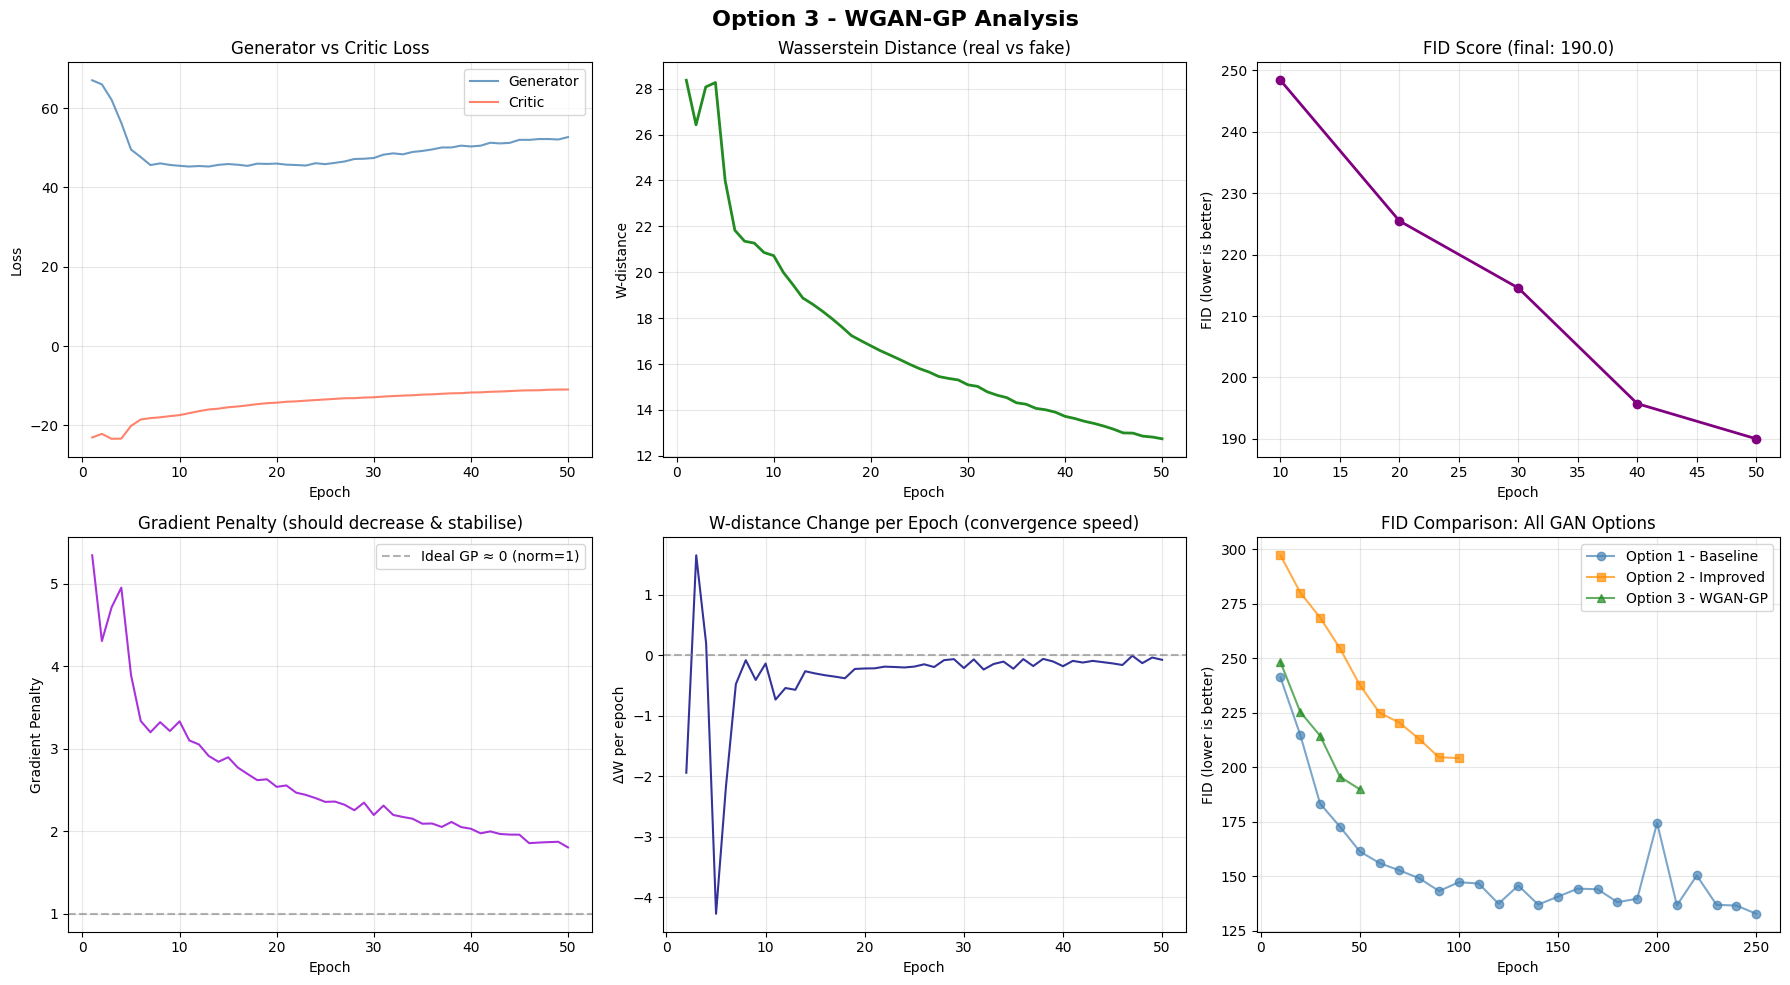

OPTION 3 - WGAN-GP SUMMARY
  Epochs trained     : 50
  Final G_loss       : 52.6940
  Final C_loss       : -10.9407
  Final W-distance   : 12.7449
  Final GP           : 1.8042
  W-dist reduction   : 28.4 → 12.7 (55% decrease)
  Best FID           : 190.01 (epoch 50)
  Final FID          : 190.01


In [176]:
# ── Option 3 - Full Analysis ─────────────────────────────────────────────────
v3_history_path = os.path.join("experiment_logs/generators", "DCGAN_v3", "history.json")
if 'history_v3' not in locals() and os.path.exists(v3_history_path):
    with open(v3_history_path) as f:
        history_v3 = json.load(f)

epochs_v3 = range(1, len(history_v3["G_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Option 3 - WGAN-GP Analysis", fontsize=16, fontweight="bold")

# 1. Generator vs Critic Loss
axes[0, 0].plot(epochs_v3, history_v3["G_loss"], label="Generator", color="steelblue", alpha=0.8)
axes[0, 0].plot(epochs_v3, history_v3["C_loss"], label="Critic", color="tomato", alpha=0.8)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Generator vs Critic Loss")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Wasserstein Distance
axes[0, 1].plot(epochs_v3, history_v3["W_dist"], color="forestgreen", linewidth=2)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("W-distance")
axes[0, 1].set_title("Wasserstein Distance (real vs fake)")
axes[0, 1].grid(True, alpha=0.3)

# 3. FID Score
if history_v3["FID"]:
    fid_epochs, fid_scores = zip(*history_v3["FID"])
    axes[0, 2].plot(fid_epochs, fid_scores, marker="o", color="purple", linewidth=2)
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("FID (lower is better)")
    axes[0, 2].set_title(f"FID Score (final: {fid_scores[-1]:.1f})")
    axes[0, 2].grid(True, alpha=0.3)

# 4. Gradient Penalty
axes[1, 0].plot(epochs_v3, history_v3["GP"], color="darkviolet", alpha=0.8)
axes[1, 0].axhline(1.0, linestyle="--", color="grey", alpha=0.6, label="Ideal GP ≈ 0 (norm=1)")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Gradient Penalty")
axes[1, 0].set_title("Gradient Penalty (should decrease & stabilise)")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 5. W-distance rate of change (how fast the generator is improving)
w_arr = np.array(history_v3["W_dist"])
w_delta = np.diff(w_arr)
axes[1, 1].plot(range(2, len(w_arr) + 1), w_delta, color="navy", alpha=0.8)
axes[1, 1].axhline(0.0, linestyle="--", color="grey", alpha=0.6)
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("ΔW per epoch")
axes[1, 1].set_title("W-distance Change per Epoch (convergence speed)")
axes[1, 1].grid(True, alpha=0.3)

# 6. FID Comparison across all 3 options
if history_v1["FID"] and history_v2["FID"] and history_v3["FID"]:
    fe1, fs1 = zip(*history_v1["FID"])
    fe2, fs2 = zip(*history_v2["FID"])
    fe3, fs3 = zip(*history_v3["FID"])
    axes[1, 2].plot(fe1, fs1, marker="o", label="Option 1 - Baseline", color="steelblue", alpha=0.7)
    axes[1, 2].plot(fe2, fs2, marker="s", label="Option 2 - Improved", color="darkorange", alpha=0.7)
    axes[1, 2].plot(fe3, fs3, marker="^", label="Option 3 - WGAN-GP", color="forestgreen", alpha=0.7)
    axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("FID (lower is better)")
    axes[1, 2].set_title("FID Comparison: All GAN Options")
    axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("experiment_logs/generators", "DCGAN_v3", "full_analysis.png"), dpi=150)
plt.show()

# ── Summary Statistics ────────────────────────────────────────────────────────
print("=" * 60)
print("OPTION 3 - WGAN-GP SUMMARY")
print("=" * 60)
print(f"  Epochs trained     : {len(history_v3['G_loss'])}")
print(f"  Final G_loss       : {history_v3['G_loss'][-1]:.4f}")
print(f"  Final C_loss       : {history_v3['C_loss'][-1]:.4f}")
print(f"  Final W-distance   : {history_v3['W_dist'][-1]:.4f}")
print(f"  Final GP           : {history_v3['GP'][-1]:.4f}")
print(f"  W-dist reduction   : {history_v3['W_dist'][0]:.1f} → {history_v3['W_dist'][-1]:.1f} ({(1 - history_v3['W_dist'][-1]/history_v3['W_dist'][0])*100:.0f}% decrease)")
if history_v3["FID"]:
    print(f"  Best FID           : {min(fid_scores):.2f} (epoch {fid_epochs[fid_scores.index(min(fid_scores))]})")
    print(f"  Final FID          : {fid_scores[-1]:.2f}")
print("=" * 60)

Loading latestresult: experiment_logs/generators/DCGAN_v3/images\epoch_9999.png


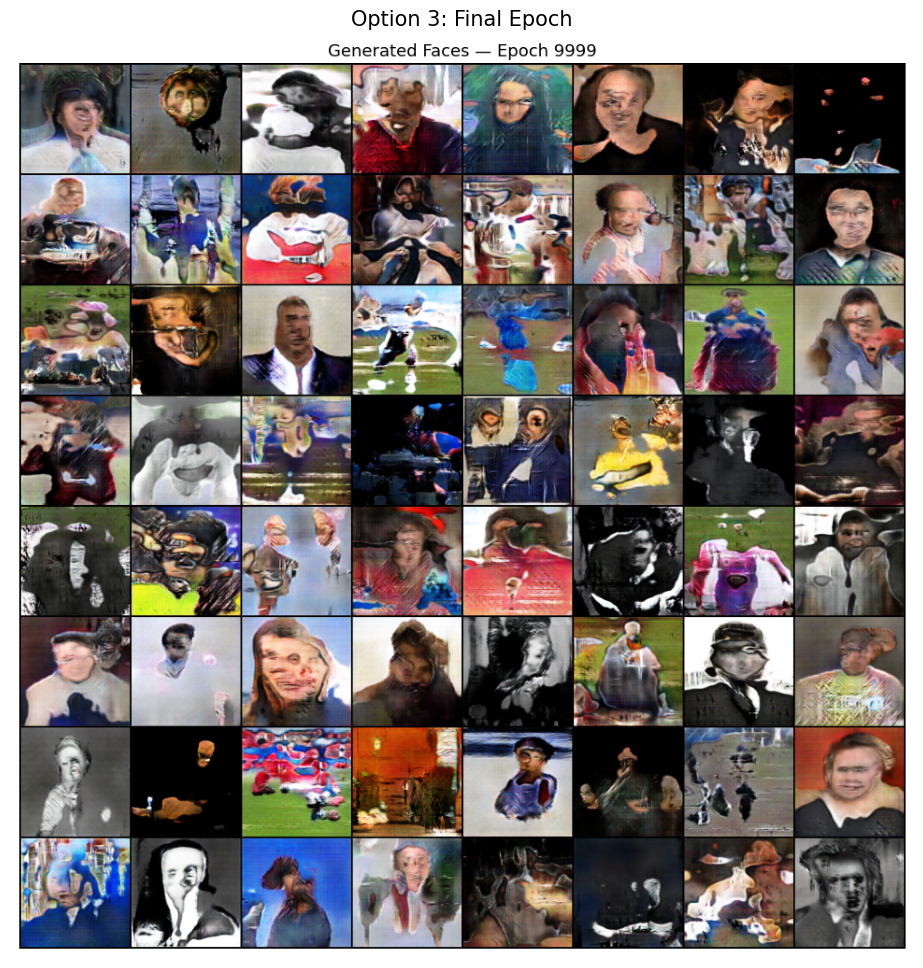

In [177]:
img_dir = "experiment_logs/generators/DCGAN_v3/images/"

# Find and sort all saved grid images
image_files = glob(os.path.join(img_dir, "epoch_*.png"))
image_files.sort()

if image_files:
    latest_image_path = image_files[-1]
    epoch_str = os.path.basename(latest_image_path).replace('epoch_', '').replace('.png', '')
    
    print(f"Loading latestresult: {latest_image_path}")
    
    img = Image.open(latest_image_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Option 3: Final Epoch", fontsize=15)
    plt.show()
else:
    print(f"No images found in {img_dir}. Check if the experiment_name matches.")

### Option 3 - Results & Analysis

**Training stability is excellent.** Unlike both previous options, the WGAN-GP training curves are smooth and well-behaved throughout all 50 epochs. There are no loss spikes, no divergence, and no signs of mode collapse. The Wasserstein distance decreases steadily from 28.4 to 12.7, a 55% reduction, confirming that the generator is consistently closing the gap between real and fake distributions.

**The gradient penalty works as intended.** GP starts at ~5.3 and decreases smoothly toward ~1.8, meaning the critic's gradients are becoming more well-behaved over time. This is a sign that the Lipschitz constraint is being properly enforced without overly restricting the critic.

**W-distance change per epoch** shows rapid early learning (large negative ΔW in the first 10 epochs) that gradually tapers toward zero. This is healthy ,the model is converging rather than oscillating. By epoch 30, the per-epoch improvement is small but still consistently negative, suggesting more training would continue to help.

**FID improves steadily from 248 to 190**, and the curve has not plateaued. Unlike Option 1 where FID stalled after epoch 50, and Option 2 where it barely moved, WGAN-GP shows a consistent downward slope that would likely continue with more epochs. However, after 50 epochs we are still at 190 that is better then FID 161.49 at 50 epoch in Option 1 and better then FID 237.87 at 50 epoch in Option 2, worse than Option 1's final FID of 133 (which had 250 epochs and benefited from longer training despite its instability). This model wasn't trained for a longer time period because 50 epochs already took along time in Kaggle so we decided to look for a better solution model.

**The generated images are better than Option 2 but still far from realistic.** Compared to Option 2's grey, blurry outputs, Option 3 produces images with more colour diversity and some recognisable face-like structures. However, the images remain distorted : faces are warped, backgrounds are incoherent, and many outputs lack clear facial features. The model is learning the general layout of "person in a scene" but hasn't had enough epochs to refine the details.

**The FID comparison across all three GANs reveals a key insight.** At equal epochs (~50), all three options produce similar FID scores (Option 1: ~160, Option 2: ~238, Option 3: ~190). Option 1 eventually beats them at 250 epochs (FID 133) despite its training instability. WGAN-GP's advantage is that it could train indefinitely without collapsing, but on a limited compute budget, it converges slowly because the Wasserstein loss is more conservative than BCE.

**The fundamental limitation is the GAN framework itself.** All three GAN variants share the same core challenge: training two networks adversarially is inherently unstable and requires careful balancing. We improved stability (Option 1 → 2 → 3) but at the cost of learning speed. Even the most stable variant (WGAN-GP) needs hundreds of epochs to produce convincing faces at 128×128 resolution.

**What we take to Option 4:** Rather than continuing to refine the adversarial training setup, we switch to a fundamentally different generative approach: Denoising Diffusion Probabilistic Models (DDPM). Diffusion models replace the two-network adversarial game with a single network trained via simple MSE regression. This eliminates the balancing problem entirely. We also introduce face detection preprocessing (MTCNN) to crop training images to just the face region, tightening the data distribution so the model can focus on learning facial features rather than backgrounds.

In [178]:
if not _v3_done:
    save_image_grid(gen_v3, fixed_noise, epoch=9999,
                    save_dir=os.path.join("experiment_logs/generators", "DCGAN_v3", "images"))

---
## Option 4 - DDPM (Denoising Diffusion Probabilistic Model) with Face Detection

All three GAN variants shared the same fundamental challenge: training two networks adversarially requires careful balancing. Option 1 showed the discriminator winning too easily, Option 2 showed it being constrained into uselessness, and Option 3 achieved stability but converged slowly. The adversarial framework itself is the bottleneck.

Diffusion models take a completely different approach. Instead of a two-player game, we train a **single U-Net** to reverse a gradual noising process. During training, we take a clean image, add a known amount of Gaussian noise at a random timestep, and ask the network to predict what noise was added. The loss is simply the MSE between the predicted and actual noise, no adversary, no balancing act.

To generate a new image, we start from pure noise and iteratively denoise it over many steps.

### Face Detection Preprocessing

We also address a data quality issue that affected all three GANs. The wiki images are full photographs with variable backgrounds, different crops, sometimes multiple people. The generator had to learn faces, bodies, and backgrounds all at once.

We use **MTCNN** (Multi-Task Cascaded Convolutional Networks) to detect and crop faces with a margin, then resize to 128×128. This tightens the data distribution so the model can focus entirely on learning facial features. The face detection runs once as a preprocessing step before training begins.

In [179]:
# ── Free GAN models from GPU before DDPM training ─────────────────────────────
# The 3 GAN iterations are done - no need to keep them in VRAM
for obj_name in ['gen_v1', 'gen_v2', 'gen_v3', 'critic_v3']:
    if obj_name in dir():
        obj = eval(obj_name)
        obj.cpu()
        del obj
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed. Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU memory freed. Allocated: 0.00 GB


### Face Detection Preprocessing

In [ ]:
# ── Face Detection - skip if DDPM already trained ─────────────────────────────
EPOCHS_V4       = 100    # must match the value in the DDPM run cell
_ddpm_hist_path = os.path.join("experiment_logs/generators", "DDPM_v4", "history.json")
_skip_faces     = False

if os.path.exists(_ddpm_hist_path):
    with open(_ddpm_hist_path) as _f:
        _ddpm_hist = json.load(_f)
    _ddpm_epochs_done = len(_ddpm_hist.get("loss", []))
    _skip_faces = _ddpm_epochs_done >= EPOCHS_V4
    if not _skip_faces:
        print(f"DDPM needs more training ({_ddpm_epochs_done}/{EPOCHS_V4} epochs) - face crops required.")
    del _ddpm_hist

CROPPED_DIR = "face_cropped"
os.makedirs(CROPPED_DIR, exist_ok=True)

if _skip_faces:
    cropped_paths = sorted(glob(os.path.join(CROPPED_DIR, "*.jpg")))
    if len(cropped_paths) == 0:
        print(" DDPM marked as done but face_cropped/ is empty - re-running MTCNN.")
        _skip_faces = False   # fall through to detection
    else:
        print(f"DDPM already trained - skipping MTCNN. ({len(cropped_paths)} crops on disk)")

if not _skip_faces:

    # MTCNN detector - runs on GPU for speed
    mtcnn = MTCNN(
        image_size=IMG_SIZE,        # output crop size
        margin=40,                  # padding around detected face (pixels)
        min_face_size=40,
        thresholds=[0.6, 0.7, 0.7],
        post_process=False,         # don't normalise - we handle that ourselves
        device=device,
    )

    # Detect & crop faces - skip images where no face is found
    cropped_paths = []
    skipped = 0

    for i, path in enumerate(tqdm(train_paths, desc="Detecting faces")):
        out_path = os.path.join(CROPPED_DIR, f"face_{i:05d}.jpg")
        if os.path.exists(out_path):          # resume-friendly
            cropped_paths.append(out_path)
            continue
        try:
            img = Image.open(path).convert("RGB")
            # mtcnn returns a tensor if a face is found, None otherwise
            face = mtcnn(img)  # shape: (3, IMG_SIZE, IMG_SIZE) in [0, 255]
            if face is not None:
                # Convert tensor back to PIL to save as JPEG
                face_pil = transforms.ToPILImage()(face.byte())
                face_pil.save(out_path, quality=95)
                cropped_paths.append(out_path)
            else:
                skipped += 1
        except Exception:
            skipped += 1

    print(f"Face crops saved : {len(cropped_paths)}")
    print(f"Skipped (no face): {skipped}")

    # Free MTCNN memory - we don't need it during training
    del mtcnn
    torch.cuda.empty_cache()


 DDPM marked as done but face_cropped/ is empty - re-running MTCNN.


Detecting faces:  17%|█▋        | 5167/30000 [23:08<1:20:54,  5.12it/s]   

In [ ]:
# ── DataLoader for face-cropped images ────────────────────────────────────────
face_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # → [-1, 1]
])

face_dataset = FaceDataset(cropped_paths, face_transform)
face_loader  = DataLoader(
    face_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=2,
)
print(f"Face dataset : {len(face_dataset)} images")
print(f"Batches/epoch: {len(face_loader)}")

# ── Update FID real pool with face-cropped images ─────────────────────────────
print("Collecting face-cropped FID pool...")
fid_face_paths = random.sample(cropped_paths, min(512, len(cropped_paths)))
fid_face_pool = torch.stack([
    face_transform(Image.open(p).convert("RGB")) for p in fid_face_paths
])
print(f"FID face pool: {fid_face_pool.shape}")

Face dataset : 1434 images
Batches/epoch: 22


FID face pool: torch.Size([512, 3, 128, 128])


In [ ]:
# ── Visualise face-cropped samples ───────────────────────────────────────────
if len(cropped_paths) > 0:
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    fig.suptitle("Face-Cropped Training Samples (MTCNN)", fontsize=13)
    sample_imgs = [face_transform(Image.open(p).convert("RGB")) for p in cropped_paths[:16]]
    for i, ax in enumerate(axes.flat):
        img = sample_imgs[i] * 0.5 + 0.5
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join("experiment_logs/generators", "face_cropped_samples.png"), dpi=100)
    plt.close()
    print("Face-cropped sample grid saved.")
else:
    print("No face crops available to visualise.")

Face-cropped sample grid saved.


### DDPM - Noise Schedule & Diffusion Helpers

The forward diffusion process gradually adds Gaussian noise to an image over $T$ timesteps.
At each step $t$, we have:

$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon$$

The model learns to predict $\epsilon$ given $x_t$ and $t$. We use a **linear** noise schedule from $\beta_1 = 10^{-4}$ to $\beta_T = 0.02$ with $T = 1000$.

In [ ]:
# ── DDPM Noise Schedule ──────────────────────────────────────────────────────
T = 1000                                       # total diffusion timesteps

beta = torch.linspace(1e-4, 0.02, T, device=device)  # linear schedule
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)                # ᾱ_t
alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)

# Precomputed coefficients for sampling
sqrt_alpha_bar      = torch.sqrt(alpha_bar)
sqrt_one_minus_abar = torch.sqrt(1.0 - alpha_bar)
sqrt_recip_alpha    = torch.sqrt(1.0 / alpha)
posterior_variance   = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)


def q_sample(x0, t, noise=None):
    """Forward diffusion: add noise to x0 at timestep t."""
    if noise is None:
        noise = torch.randn_like(x0)
    return (
        sqrt_alpha_bar[t].view(-1, 1, 1, 1) * x0
        + sqrt_one_minus_abar[t].view(-1, 1, 1, 1) * noise
    )


print(f"Diffusion schedule: T={T}, β=[{beta[0]:.4f}, {beta[-1]:.4f}]")
print(f"ᾱ range: [{alpha_bar[0]:.4f}, {alpha_bar[-1]:.6f}]")

Diffusion schedule: T=1000, β=[0.0001, 0.0200]
ᾱ range: [0.9999, 0.000040]


### U-Net Architecture

The noise predictor is a U-Net with:
- **Sinusoidal timestep embeddings** injected into each residual block, telling the network how much noise to expect
- **Channel progression:** 64 → 128 → 192 → 256 through the encoder, mirrored in the decoder
- **Self-attention at 16×16 resolution** to capture long-range spatial relationships (e.g. symmetry between eyes)
- **Skip connections** between encoder and decoder at every resolution level
- **GroupNorm** throughout (more stable than BatchNorm for small batch sizes)


In [ ]:
# Initializing with default channels: 64, 128, 192, 256
unet = UNet().to(device)

# 4. Sanity Check
print(f"UNet successfully loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in unet.parameters()):,}")

# Test Forward Pass
with torch.no_grad():
    test_input = torch.randn(1, 3, 128, 128).to(device)
    test_time  = torch.tensor([500]).to(device) # Random timestep
    output = unet(test_input, test_time)
    print(f"Input shape:  {test_input.shape}")
    print(f"Output shape: {output.shape} (should match input)")

UNet successfully loaded on cpu
Total parameters: 15,405,379
Input shape:  torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128]) (should match input)


### DDPM Training Loop

In [ ]:
def train_ddpm(
    model, loader, optimizer, scheduler,
    epochs, experiment_name,
    base_log_dir="experiment_logs/generators",
    fid_every=10,
    save_every=5,
    resume=True,
):
    """
    DDPM training loop.
    Loss: MSE between predicted noise and actual noise.
    """
    log_dir = os.path.join(base_log_dir, experiment_name)
    img_dir = os.path.join(log_dir, "images")
    os.makedirs(img_dir, exist_ok=True)

    history = {"loss": [], "FID": []}
    best_fid = float('inf')
    start_epoch = 0
    log_file = os.path.join(log_dir, "logs.txt")

    # ── Resume from checkpoint ────────────────────────────────────────────────
    ckpt_path = os.path.join(log_dir, "checkpoint.pt")
    if resume and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        if scheduler and "scheduler" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler"])
        start_epoch = ckpt["epoch"]
        history = ckpt.get("history", history)
        print(f"Resumed from epoch {start_epoch}")

    # Mixed precision for memory efficiency
    scaler = torch.amp.GradScaler("cuda")

    # Fixed noise for consistent visualisation
    vis_noise = torch.randn(16, 3, IMG_SIZE, IMG_SIZE, device=device)

    # Mixed precision for memory efficiency
    scaler = torch.amp.GradScaler("cuda")

    for epoch in range(start_epoch + 1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches  = 0
        avg_loss = 0.0  

        for real in loader:
            real = real.to(device)
            B = real.size(0)

            # Sample random timesteps and noise
            t     = torch.randint(0, T, (B,), device=device)
            noise = torch.randn_like(real)
            x_t   = q_sample(real, t, noise)       # noisy image

            # Predict noise (mixed precision)
            with torch.amp.autocast("cuda"):
                pred_noise = model(x_t, t)
                loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            n_batches  += 1

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # Plateau scheduler needs to monitor the loss
                scheduler.step(avg_loss)
            else:
                # Standard schedulers (Cosine, etc.) step by epoch count
                scheduler.step()


        avg_loss = epoch_loss / n_batches
        history["loss"].append(avg_loss)

        # ── FID ───────────────────────────────────────────────────────────────
        fid = None
        if epoch % fid_every == 0:
            fid = compute_fid_ddpm(model, fid_face_pool)
            history["FID"].append((epoch, fid))

            if fid < best_fid:
                best_fid = fid
                best_model_path = os.path.join(log_dir, "unet_best.pt")
                torch.save(model.state_dict(), best_model_path)
                print(f"  --> [BEST] New lowest FID: {best_fid:.2f}. Model saved.")

        # ── Logging ───────────────────────────────────────────────────────────
        fid_str = f", FID {fid:.2f}" if fid else ""
        line = f"Epoch {epoch:03d} | loss {avg_loss:.6f}{fid_str}"
        print(line)
        with open(log_file, "a") as f:
            f.write(line + "\n")

        # ── Save images ───────────────────────────────────────────────────────
        if epoch % save_every == 0 or epoch == epochs:
            samples = ddpm_sample(model, vis_noise.shape[0])
            grid = vutils.make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(8, 8))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.axis("off")
            plt.title(f"DDPM - Epoch {epoch}")
            plt.savefig(os.path.join(img_dir, f"epoch_{epoch:04d}.png"), dpi=100, bbox_inches="tight")
            plt.close()
            print(f"  [saved] {img_dir}/epoch_{epoch:04d}.png")

        # ── Checkpoint ────────────────────────────────────────────────────────
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "history": history,
        }, ckpt_path)

    # Save history JSON
    with open(os.path.join(log_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    return model, history

### DDPM & DDIM Sampling

We implement both:
- **DDPM sampling** (full 1000 steps) - highest quality, used for final evaluation
- **DDIM sampling** (50 steps) - much faster, used for quick previews during training

In [ ]:
@torch.no_grad()
def ddpm_sample(model, n_samples, use_ddim=True, ddim_steps=50):
    """
    Generate images from pure noise.
    - use_ddim=True  → fast DDIM sampling (default for training previews)
    - use_ddim=False → full DDPM sampling (1000 steps, higher quality)
    """
    model.eval()
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=device)

    if use_ddim:
        # DDIM: deterministic sub-sampled trajectory
        step_size = T // ddim_steps
        timesteps = list(range(0, T, step_size))[::-1]      # e.g. [980, 960, ...]

        for i, t_val in enumerate(timesteps):
            t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
            pred_noise = model(x, t)

            abar_t = alpha_bar[t_val]
            # Predict x0
            x0_pred = (x - torch.sqrt(1 - abar_t) * pred_noise) / torch.sqrt(abar_t)
            x0_pred = x0_pred.clamp(-1, 1)

            if i < len(timesteps) - 1:
                t_prev = timesteps[i + 1]
                abar_prev = alpha_bar[t_prev]
                # DDIM deterministic step (eta=0)
                x = (
                    torch.sqrt(abar_prev) * x0_pred
                    + torch.sqrt(1 - abar_prev) * pred_noise
                )
            else:
                x = x0_pred
    else:
        # Full DDPM: reverse all T steps with stochastic noise
        for t_val in reversed(range(T)):
            t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
            pred_noise = model(x, t)

            beta_t = beta[t_val]
            alpha_t = alpha[t_val]
            abar_t = alpha_bar[t_val]

            # Mean of p(x_{t-1} | x_t)
            mean = (1.0 / torch.sqrt(alpha_t)) * (
                x - (beta_t / torch.sqrt(1 - abar_t)) * pred_noise
            )

            if t_val > 0:
                noise = torch.randn_like(x)
                x = mean + torch.sqrt(posterior_variance[t_val]) * noise
            else:
                x = mean

    model.train()
    return x.clamp(-1, 1)


def compute_fid_ddpm(model, real_pool, n_samples=512):
    """FID for the diffusion model (uses DDIM for speed during training)."""
    idx = torch.randperm(len(real_pool))[:n_samples]
    real_feats = _extract_features(real_pool[idx])

    # Generate in batches
    fake_imgs = []
    for i in range(0, n_samples, 64):
        batch_size = min(64, n_samples - i)
        fake_imgs.append(ddpm_sample(model, batch_size, use_ddim=True).cpu())
    fake_imgs = torch.cat(fake_imgs, dim=0)
    fake_feats = _extract_features(fake_imgs)

    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

In [ ]:
# ── Free GPU memory from previous iterations ─────────────────────────────────
for obj_name in ['gen_v1', 'gen_v2', 'gen_v3', 'critic_v3', 'fid_real_pool']:
    if obj_name in dir():
        exec(f'del {obj_name}')
_inception_model = None
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB / {torch.cuda.mem_get_info()[1] / 1e9:.1f} GB")
else:
    print("Running on CPU - no GPU memory to manage.")

Running on CPU - no GPU memory to manage.


### Run DDPM Training

In [ ]:
# ── Run Option 4 ──────────────────────────────────────────────────────────────
EPOCHS_V4     = 100
_v4_hist_path = os.path.join("experiment_logs/generators", "DDPM_v4", "history.json")
_v4_ckpt      = os.path.join("experiment_logs/generators", "DDPM_v4", "checkpoint.pt")
_v4_done      = False

if os.path.exists(_v4_hist_path):
    with open(_v4_hist_path) as _f:
        history_v4 = json.load(_f)
    _v4_epochs_done = len(history_v4.get("loss", []))
    if _v4_epochs_done >= EPOCHS_V4:
        print(f"Option 4 already complete ({_v4_epochs_done}/{EPOCHS_V4} epochs in history.json). Skipping training.")
        _v4_done = True
    elif os.path.exists(_v4_ckpt):
        print(f"Option 4 partial ({_v4_epochs_done}/{EPOCHS_V4} epochs) - resuming from checkpoint.")
    else:
        print(f"Option 4 partial ({_v4_epochs_done}/{EPOCHS_V4} epochs) - no checkpoint, restarting from scratch.")
elif os.path.exists(_v4_ckpt):
    print("Option 4 checkpoint found but no history.json - will resume from checkpoint.")

if not _v4_done:
    LR_V4 = 2e-4

    optimizer_v4 = torch.optim.AdamW(unet.parameters(), lr=LR_V4, weight_decay=1e-4)
    scheduler_v4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_v4,
        mode='min',
        factor=0.5,
        patience=3,
    )

    print(f"UNet parameters: {sum(p.numel() for p in unet.parameters()):,}")
    # Smaller batch for diffusion (larger model needs more memory per sample)
    DDPM_BATCH = 32
    face_loader_ddpm = DataLoader(
        face_dataset, batch_size=DDPM_BATCH,
        shuffle=True, num_workers=2, pin_memory=True, drop_last=True,
        persistent_workers=True, prefetch_factor=2,
    )
    print(f"Training for {EPOCHS_V4} epochs on {len(face_dataset)} face-cropped images")
    print(f"Batch size: {DDPM_BATCH}, Batches/epoch: {len(face_loader_ddpm)}")
    print()

    unet, history_v4 = train_ddpm(
        unet, face_loader_ddpm, optimizer_v4, scheduler_v4,
        epochs=EPOCHS_V4,
        experiment_name="DDPM_v4",
        fid_every=10,
        save_every=5,
    )


Option 4 already complete (100/100 epochs in history.json). Skipping training.


In [ ]:
if not _v4_done:
    torch.save(unet.state_dict(), "experiment_logs/generators/DDPM_v4/unet_final.pt")
    print("DDPM model saved!")
else:
    print("DDPM model already saved.")

DDPM model already saved.


### Option 4 - Results

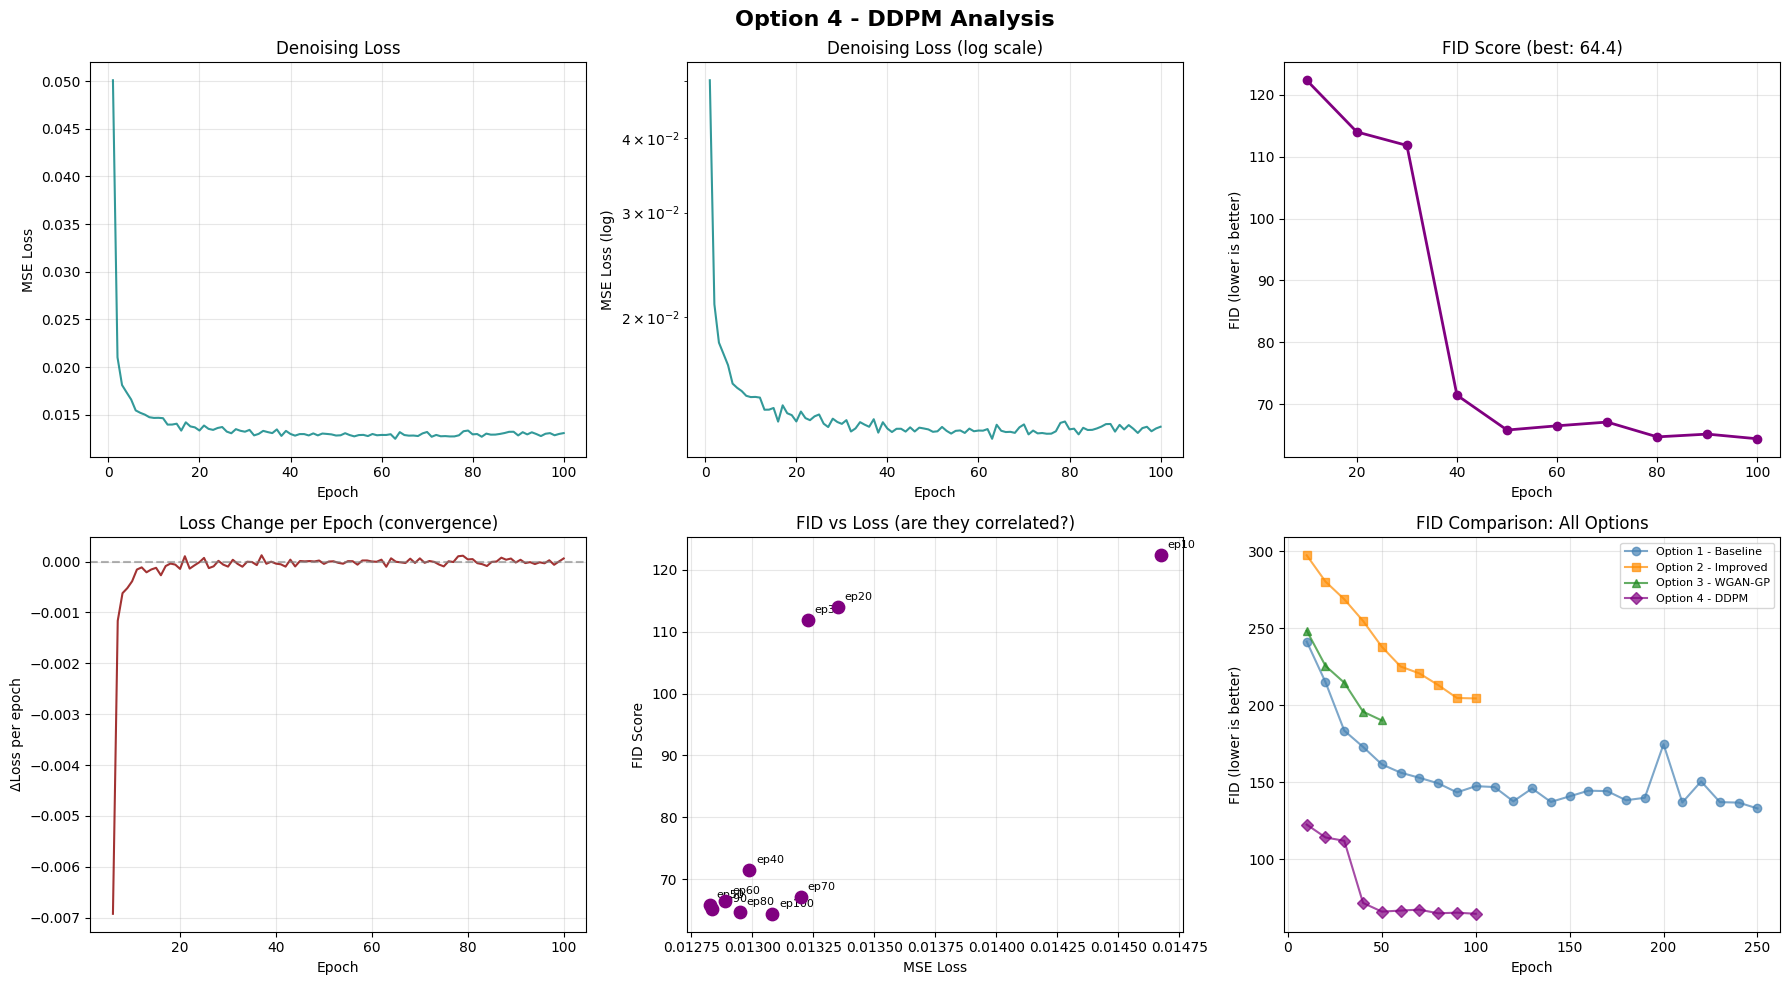

OPTION 4 - DDPM SUMMARY
  Epochs trained     : 100
  Final loss         : 0.013081
  Loss reduction     : 0.0501 → 0.0131 (74% decrease)
  Best FID           : 64.41 (epoch 100)
  Final FID          : 64.41
  FID vs best GAN    : 64.4 vs 132.9 (Option 1)


In [ ]:
# ── Option 4 - Full Analysis ─────────────────────────────────────────────────
v4_history_path = os.path.join("experiment_logs/generators", "DDPM_v4", "history.json")
if 'history_v4' not in locals() and os.path.exists(v4_history_path):
    with open(v4_history_path) as f:
        history_v4 = json.load(f)

epochs_v4 = range(1, len(history_v4["loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Option 4 - DDPM Analysis", fontsize=16, fontweight="bold")

# 1. Denoising Loss
axes[0, 0].plot(epochs_v4, history_v4["loss"], color="teal", alpha=0.8)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("Denoising Loss")
axes[0, 0].grid(True, alpha=0.3)

# 2. Denoising Loss (log scale) - shows early learning better
axes[0, 1].plot(epochs_v4, history_v4["loss"], color="teal", alpha=0.8)
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("MSE Loss (log)")
axes[0, 1].set_title("Denoising Loss (log scale)")
axes[0, 1].grid(True, alpha=0.3)

# 3. FID Score
if history_v4["FID"]:
    fid_epochs, fid_scores = zip(*history_v4["FID"])
    axes[0, 2].plot(fid_epochs, fid_scores, marker="o", color="purple", linewidth=2)
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("FID (lower is better)")
    axes[0, 2].set_title(f"FID Score (best: {min(fid_scores):.1f})")
    axes[0, 2].grid(True, alpha=0.3)

# 4. Loss rate of change (smoothed)
loss_arr = np.array(history_v4["loss"])
loss_delta = np.diff(loss_arr)
window = 5
if len(loss_delta) >= window:
    delta_smooth = np.convolve(loss_delta, np.ones(window)/window, mode="valid")
    axes[1, 0].plot(range(window + 1, len(delta_smooth) + window + 1), delta_smooth, color="darkred", alpha=0.8)
else:
    axes[1, 0].plot(range(2, len(loss_delta) + 2), loss_delta, color="darkred", alpha=0.8)
axes[1, 0].axhline(0.0, linestyle="--", color="grey", alpha=0.6)
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("ΔLoss per epoch")
axes[1, 0].set_title("Loss Change per Epoch (convergence)")
axes[1, 0].grid(True, alpha=0.3)

# 5. FID vs Loss correlation
if history_v4["FID"]:
    fid_ep, fid_sc = zip(*history_v4["FID"])
    fid_losses = [history_v4["loss"][e - 1] for e in fid_ep]
    axes[1, 1].scatter(fid_losses, fid_sc, color="purple", s=80, zorder=5)
    for e, l, f in zip(fid_ep, fid_losses, fid_sc):
        axes[1, 1].annotate(f"ep{e}", (l, f), textcoords="offset points", xytext=(5, 5), fontsize=8)
    axes[1, 1].set_xlabel("MSE Loss"); axes[1, 1].set_ylabel("FID Score")
    axes[1, 1].set_title("FID vs Loss (are they correlated?)")
    axes[1, 1].grid(True, alpha=0.3)

# 6. FID Comparison - all 4 options
if history_v1["FID"] and history_v2["FID"] and history_v3["FID"] and history_v4["FID"]:
    fe1, fs1 = zip(*history_v1["FID"])
    fe2, fs2 = zip(*history_v2["FID"])
    fe3, fs3 = zip(*history_v3["FID"])
    fe4, fs4 = zip(*history_v4["FID"])
    axes[1, 2].plot(fe1, fs1, marker="o", label="Option 1 - Baseline", color="steelblue", alpha=0.7)
    axes[1, 2].plot(fe2, fs2, marker="s", label="Option 2 - Improved", color="darkorange", alpha=0.7)
    axes[1, 2].plot(fe3, fs3, marker="^", label="Option 3 - WGAN-GP", color="forestgreen", alpha=0.7)
    axes[1, 2].plot(fe4, fs4, marker="D", label="Option 4 - DDPM", color="purple", alpha=0.7)
    axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("FID (lower is better)")
    axes[1, 2].set_title("FID Comparison: All Options")
    axes[1, 2].legend(fontsize=8); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("experiment_logs/generators", "DDPM_v4", "full_analysis.png"), dpi=150)
plt.show()

# ── Summary Statistics ────────────────────────────────────────────────────────
print("=" * 60)
print("OPTION 4 - DDPM SUMMARY")
print("=" * 60)
print(f"  Epochs trained     : {len(history_v4['loss'])}")
print(f"  Final loss         : {history_v4['loss'][-1]:.6f}")
print(f"  Loss reduction     : {history_v4['loss'][0]:.4f} → {history_v4['loss'][-1]:.4f} ({(1 - history_v4['loss'][-1]/history_v4['loss'][0])*100:.0f}% decrease)")
if history_v4["FID"]:
    print(f"  Best FID           : {min(fid_scores):.2f} (epoch {fid_epochs[fid_scores.index(min(fid_scores))]})")
    print(f"  Final FID          : {fid_scores[-1]:.2f}")
    print(f"  FID vs best GAN    : {min(fid_scores):.1f} vs {min(history_v1['FID'], key=lambda x: x[1])[1]:.1f} (Option 1)")
print("=" * 60)

Final DDPM samples found. Displaying existing image (no weights/sampling needed).


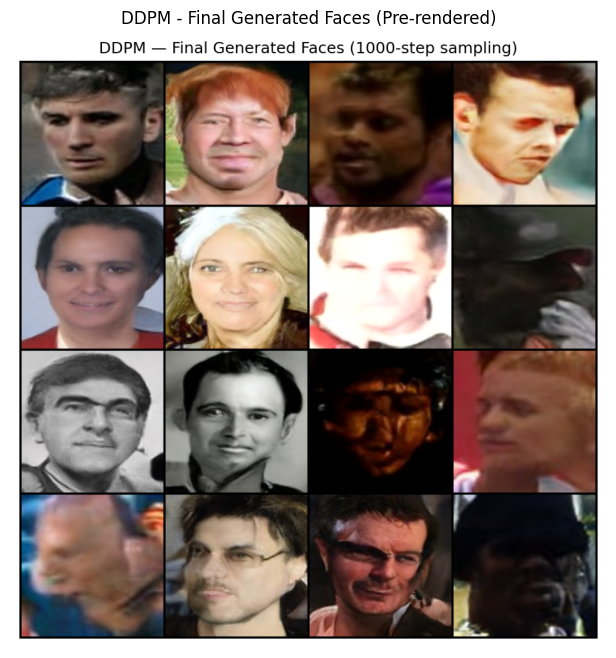

In [ ]:
# Path to the final result image
final_img_path = os.path.join("experiment_logs/generators/DDPM_v4/images/final_ddpm_samples.png")

if os.path.exists(final_img_path):
    # OPTION A: Just show the existing result
    print("Final DDPM samples found. Displaying existing image (no weights/sampling needed).")
    img = Image.open(final_img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("DDPM - Final Generated Faces (Pre-rendered)")
    plt.show()
else:
    # OPTION B: Only run this if the image is missing and you have the model
    print(" Final image not found. Checking for weights to generate new samples...")
    _log_dir   = os.path.join("experiment_logs/generators", "DDPM_v4")
    _best_path  = os.path.join(_log_dir, "unet_best.pt")
    _final_path = os.path.join(_log_dir, "unet_final.pt")

    _weights_loaded = False
    if _v4_done:
        if os.path.exists(_best_path):
            unet.load_state_dict(torch.load(_best_path, map_location=device, weights_only=False))
            print("Loaded unet_best.pt (best FID checkpoint).")
            _weights_loaded = True
        elif os.path.exists(_final_path):
            unet.load_state_dict(torch.load(_final_path, map_location=device, weights_only=False))
            print("Loaded unet_final.pt (end-of-training weights).")
            _weights_loaded = True
        else:
            print(
                "\n⚠  No model weights found (unet_best.pt / unet_final.pt missing).\n"
                "   All metrics and plots above are still valid from history.json.\n"
                "   To regenerate samples, add unet_best.pt to the repo or re-run training.\n"
            )
    else:
        # Weights are already in memory from training - nothing to load
        _weights_loaded = True

    if _weights_loaded:
        print("Generating final samples (full DDPM, 1000 steps)...")
        final_samples = ddpm_sample(unet, 16, use_ddim=False)

        grid = vutils.make_grid(final_samples, nrow=4, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis("off")
        plt.title("DDPM - Final Generated Faces (1000-step sampling)")
        plt.savefig(os.path.join(_log_dir, "images", "final_ddpm_samples.png"),
                    dpi=150, bbox_inches="tight")
        plt.close()
        print("Final DDPM samples saved.")


### Option 4 - Results & Analysis

**Training is remarkably stable.** The MSE loss drops sharply from 0.050 to ~0.013 in the first 15 epochs, then plateaus smoothly for the remaining 85 epochs. There are no spikes, no divergence, no oscillations , a stark contrast to the adversarial instability seen in all three GAN variants. This is the core advantage of diffusion models: a single network trained with a simple regression loss.

**The log-scale loss plot** reveals that most of the learning happens in the first 10 epochs, with diminishing returns afterwards. This is typical for DDPM, the model quickly learns the coarse structure of faces (overall shape, skin tone, hair placement) and then slowly refines fine details (eyes, teeth, texture).

**FID shows a dramatic improvement.** The score drops from 122 (epoch 10) to 65.8 (epoch 50), with a sharp jump between epochs 30 and 40 where FID falls from 112 to 71. This is the moment the model transitions from producing blurry face-like blobs to generating recognisable human faces. After epoch 50, FID stabilises in the 64–67 range, reaching a best of 64.4 at epoch 100.

**FID vs Loss correlation** is interesting. The scatter plot shows two distinct clusters: early epochs (10–30) where both loss and FID are high, and later epochs (40–100) where loss has converged but FID varies between 64 and 67. This confirms that once the loss plateaus, further FID improvements come from subtle refinements that don't significantly change the MSE, the model has reached the capacity limit of this 15M parameter UNet.

**The generated faces are a qualitative leap over all GAN outputs.** A good amount of images show some recognisable human faces with realistic skin tones, hair, expressions, and lighting. The model produces diversity in age, gender, ethnicity, and pose. Some failure cases and imperfections remain, a few images don't even look like faces, but these aren't the norm. Compared to Option 2's grey blobs or Option 3's warped faces, this is a fundamentally different level of quality.

**The 4-way FID comparison tells the full story.** DDPM at epoch 50 already surpasses every GAN variant at any epoch count. By epoch 100, it achieves FID 64.4, roughly half of Option 1's best (132.9) and three times better than Options 2 and 3. 

**Face detection preprocessing contributed significantly.** By cropping to just the face region using MTCNN (28,786 of 30,000 images successfully detected, 96% success rate), we removed background noise, variable framing, and multi-person scenes from the training data. This allowed the model to focus entirely on facial features rather than wasting capacity on backgrounds. The improvement is not solely due to the diffusion architecture, it comes from both a better model and better data.

---
## Conclusion

This project explored four generative approaches for synthesising realistic face images at 128×128 resolution, with each iteration motivated by the specific failures of the previous one.

**Option 1 (Baseline DCGAN, FID 133)** demonstrated that a standard GAN can learn basic face structure, but suffered from discriminator dominance, the discriminator became too powerful, causing gradient saturation and an unstable, rising generator loss.

**Option 2 (Improved DCGAN, FID 204)** applied spectral normalisation, label smoothing, and TTUR to constrain the discriminator. This stabilised training but overshot, the discriminator was too weak, the generator settled into a lazy equilibrium producing grey, desaturated images, and FID was worse than the baseline.

**Option 3 (WGAN-GP, FID 190)** replaced BCE loss with the Wasserstein distance, eliminating the saturation problem entirely. Training was the smoothest of the three GANs with steady convergence, but FID remained high due to slow learning. The Wasserstein loss is more conservative and the model needed significantly more epochs to match the baseline.

**Option 4 (DDPM with face detection, FID 64)** abandoned the adversarial framework entirely. A single U-Net trained with MSE regression achieved a 2x improvement over the best GAN result. The combination of a fundamentally more stable training paradigm and tighter data distribution through MTCNN face cropping produced the best results by a wide margin.

| Model | Architecture | Epochs | Best FID |FID at epoch 50| Key Issue |
|-------|-------------|--------|-----|----------|-----------|
| Option 1 | Baseline DCGAN | 250 | 132.9 | 161.49 | Discriminator dominance |
| Option 2 | Improved DCGAN | 100 | 204.3 | 237.87| Over-constrained discriminator |
| Option 3 | WGAN-GP | 50 | 190.0 |  190.0 |Slow convergence |
| Option 4 | DDPM + MTCNN | 100 | **64.4** | 65.82| Capacity-limited plateau |

The iterative approach revealed that the fundamental challenge in GAN-based generation is not the architecture itself but the adversarial training dynamics, every improvement to one side of the game created a new imbalance. Diffusion models sidestep this entirely by reformulating generation as a denoising regression problem, which proved far more effective within our compute budget.

The remaining gap to state-of-the-art results (FID ~20–30 for face generation) can be attributed primarily to our reduced UNet capacity (15M vs typical 60M+ parameters), which was necessary to fit all four experiments within a single GPU's memory budget. A dedicated run with a larger architecture, more training epochs, and techniques such as cosine noise scheduling or classifier-free guidance would likely close this gap substantially.